<a href="https://colab.research.google.com/github/PaulinaG27/Ciencia-Datos/blob/main/sesiones_practicas/sp_final_Julian_Isaza_Marin_Paulina_Garcia_Aristizabal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="background-color:#1a3a5c; padding:20px; border-radius:10px; text-align:center;">
  <h1 style="color:white; font-size:24px;">🏠 Análisis del precio de arrendamiento de viviendas en India</h1>
  <h3 style="color:#aad4f5; font-size:16px;">Proyecto Final — Modelos y Simulación de Sistemas II</h3>
  <p style="color:#cce0f5;">Julián Isaza Marín &nbsp;|&nbsp; Maria Cristina Vergara Quinchía &nbsp;|&nbsp; Andrea Correa Arango<br>
  Universidad de Antioquia — Ingeniería de Sistemas</p>
</div>

---
## <span style="color:#2F749F;"><strong>0. Configuración del entorno y carga de datos</strong></span>

In [ ]:
# Librerías estándar de análisis de datos
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import shapiro, kstest, kruskal, chi2_contingency, pearsonr, spearmanr
from sklearn.preprocessing import StandardScaler, LabelEncoder, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import LocalOutlierFactor
from sklearn.ensemble import IsolationForest
from sklearn.impute import KNNImputer
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
sns.set_theme(style='whitegrid', palette='muted')

In [ ]:
# Descarga del Dataset
import kagglehub
import os
house_rent_path = kagglehub.dataset_download('iamsouravbanerjee/house-rent-prediction-dataset')

csv_file_path = os.path.join(house_rent_path, 'House_Rent_Dataset.csv')
df_raw = pd.read_csv(csv_file_path)
print(f"Dataset cargado: {df_raw.shape[0]:,} registros, {df_raw.shape[1]} variables")
df_raw.head()

100%|██████████| 82.4k/82.4k [00:00<00:00, 17.0MB/s]

Extracting files...
Dataset cargado: 4,746 registros, 12 variables


,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


## <span style="color:#2F749F;"><strong>1. Comprensión y descripción del conjunto de datos</strong></span>

El mercado de arrendamiento residencial en India representa uno de los sectores más dinámicos y complejos de la economía del país. Con una población superior a 1.400 millones de habitantes y una creciente migración hacia centros urbanos, la determinación del precio de renta se convierte en un problema de alta relevancia social y económica: afecta directamente la calidad de vida de millones de familias que no acceden a vivienda propia y constituye una decisión crítica tanto para arrendadores como para arrendatarios.

El dataset donde vamos a trabajar que lleva por nombre **House Rent Prediction Dataset** (Banerjee, 2022) recopila información sobre propiedades en arrendamiento publicadas en plataformas digitales en seis de las principales ciudades de India: Mumbai, Delhi, Bangalore, Hyderabad, Chennai y Kolkata. Contiene **4.746 registros** y **12 variables** que describen características físicas del inmueble, su ubicación geográfica y las condiciones del arrendamiento.

Sin embargo, es importante reconocer sus limitaciones desde el inicio: Según el autor del dataset, los registros provienen de plataformas digitales de anuncios inmobiliarios (Barnerjee, 2022) lo que excluye el mercado informal de arrendamiento. Adicionalmente, aunque la cobertura incluye las seis ciudades más pobladas del país, las conclusiones tienen mayor validez para grandes centros urbanos con mercados digitalizados, y no necesariamente son extrapolables a ciudades intermedias, zonas semiurbanas o mercados informales de arrendamiento.

In [ ]:
# 1.1 Estructura general
print("="*55)
print(f"  Registros : {df_raw.shape[0]:,}")
print(f"  Variables : {df_raw.shape[1]}")
print("="*55)
df_raw.info()

  Registros : 4,746
  Variables : 12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [ ]:
#  1.2 Descripción de variables
descripcion = pd.DataFrame({
    'Variable': ['Posted On', 'BHK', 'Rent', 'Size', 'Floor',
                 'Area Type', 'Area Locality', 'City',
                 'Furnishing Status', 'Tenant Preferred', 'Bathroom', 'Point of Contact'],
    'Tipo original': ['object (fecha)', 'int64', 'int64', 'int64', 'object',
                      'object', 'object', 'object', 'object', 'object', 'int64', 'object'],
    'Tipo semántico': ['Temporal', 'Numérica discreta', 'Numérica continua', 'Numérica continua',
                       'Categórica ordinal', 'Categórica nominal', 'Categórica nominal',
                       'Categórica nominal', 'Categórica ordinal', 'Categórica nominal',
                       'Numérica discreta', 'Categórica nominal'],
    'Descripción': ['Fecha de publicación del anuncio', 'Número de habitaciones (Bedroom-Hall-Kitchen)',
                    'Precio mensual del arriendo (INR)', 'Área en pies cuadrados',
                    'Piso donde se ubica la propiedad', 'Tipo de medición del área',
                    'Barrio o zona de la ciudad', 'Ciudad de la propiedad',
                    'Nivel de amueblado', 'Tipo de inquilino preferido',
                    'Número de baños', 'Medio de contacto']
})
print(descripcion.to_string(index=False))

         Variable  Tipo original     Tipo semántico                                   Descripción
        Posted On object (fecha)           Temporal              Fecha de publicación del anuncio
              BHK          int64  Numérica discreta Número de habitaciones (Bedroom-Hall-Kitchen)
             Rent          int64  Numérica continua             Precio mensual del arriendo (INR)
             Size          int64  Numérica continua                        Área en pies cuadrados
            Floor         object Categórica ordinal              Piso donde se ubica la propiedad
        Area Type         object Categórica nominal                     Tipo de medición del área
    Area Locality         object Categórica nominal                    Barrio o zona de la ciudad
             City         object Categórica nominal                        Ciudad de la propiedad
Furnishing Status         object Categórica ordinal                            Nivel de amueblado
 Tenant Preferred   

In [ ]:
# 1.3 Estadísticas descriptivas generales
df_raw.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Posted On,4746,81,2022-07-06,311,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BHK,4746.0,NaN,NaN,NaN,2.08386,0.832256,1.0,2.0,2.0,3.0,6.0
Rent,4746.0,NaN,NaN,NaN,34993.451327,78106.412937,1200.0,10000.0,16000.0,33000.0,3500000.0
Size,4746.0,NaN,NaN,NaN,967.490729,634.202328,10.0,550.0,850.0,1200.0,8000.0
Floor,4746,480,1 out of 2,379,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Type,4746,3,Super Area,2446,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Area Locality,4746,2235,Bandra West,37,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,4746,6,Mumbai,972,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Furnishing Status,4746,3,Semi-Furnished,2251,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenant Preferred,4746,3,Bachelors/Family,3444,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---
## <span style="color:#2F749F;"><strong>1.5 Consideraciones éticas y análisis de sesgo</strong></span>

Antes de proceder con el análisis, es necesario reflexionar sobre las implicaciones éticas del uso de este conjunto de datos, siguiendo los principios de la **ética en ciencia de datos** y el marco **Privacy by Design**.

### <span style="color:#1a7a4a;"><strong>1.5.2 Análisis de sesgo (Bias)</strong></span>

El sesgo en los datos puede comprometer la validez de cualquier conclusión analítica. Se identifican los siguientes tipos de sesgo potencial en este dataset:

- **Sesgo de muestreo:** el dataset cubre las seis ciudades más pobladas de India con una distribución relativamente equilibrada entre ellas (razón máx/mín de 1.9x). Las conclusiones tienen mayor validez para grandes centros urbanos con mercados digitalizados, y no son directamente extrapolables a ciudades intermedias o mercados informales.
- **Sesgo de selección:** los registros provienen de anuncios publicados en plataformas digitales, lo que excluye el mercado informal de arrendamiento, que en India representa una fracción significativa del total. Adicionalmente,  la variable `Tenant Preferred` refleja las preferencias declaradas por el arrendador, lo que puede incorporar discriminación implícita por tipo de familia o género.

A continuación se cuantifica el sesgo de muestreo mediante la distribución geográfica del dataset.

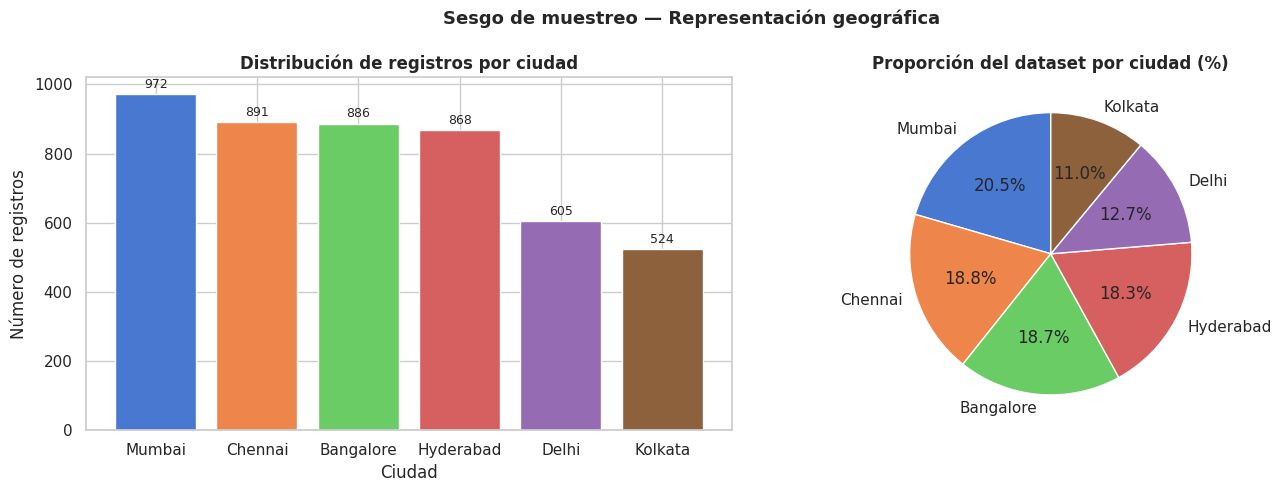


 Distribución por ciudad:
           Registros  Porcentaje (%)
City                                
Mumbai           972            20.5
Chennai          891            18.8
Bangalore        886            18.7
Hyderabad        868            18.3
Delhi            605            12.7
Kolkata          524            11.0


In [ ]:
# 1.5.2 CUANTIFICACIÓN DEL SESGO DE MUESTREO
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución absoluta por ciudad
city_counts = df_raw['City'].value_counts()
bars = axes[0].bar(city_counts.index, city_counts.values,
                   color=sns.color_palette('muted', len(city_counts)),
                   edgecolor='white')
axes[0].set_title('Distribución de registros por ciudad', fontweight='bold')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Número de registros')
for bar, val in zip(bars, city_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', va='bottom', fontsize=9)

# Distribución porcentual (evidencia el desbalance)
pct_city = (city_counts / city_counts.sum() * 100).round(1)
axes[1].pie(pct_city.values, labels=pct_city.index,
            autopct='%1.1f%%', startangle=90,
            colors=sns.color_palette('muted', len(city_counts)))
axes[1].set_title('Proporción del dataset por ciudad (%)', fontweight='bold')

plt.suptitle('Sesgo de muestreo — Representación geográfica',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Resumen numérico
print("\n Distribución por ciudad:")
resumen_ciudad = pd.DataFrame({
    'Registros': city_counts,
    'Porcentaje (%)': pct_city
})
print(resumen_ciudad.to_string())


### Análisis:
La muestra exhibe una distribución geográfica relativamente equilibrada entre las seis ciudades evaluadas. Mumbai se posiciona como la ciudad con mayor representatividad, concentrando el 20.5% de los registros, mientras que Kolkata registra la menor participación con un 11.0%. Al evaluar la relación entre ambos extremos, se obtiene una razón de 1.9x; estadísticamente, esta proporción representa un desbalance leve en la densidad de los datos, por lo que se determina que no existe una asimetría o sesgo de selección geográfica que comprometa la representatividad de la muestra.

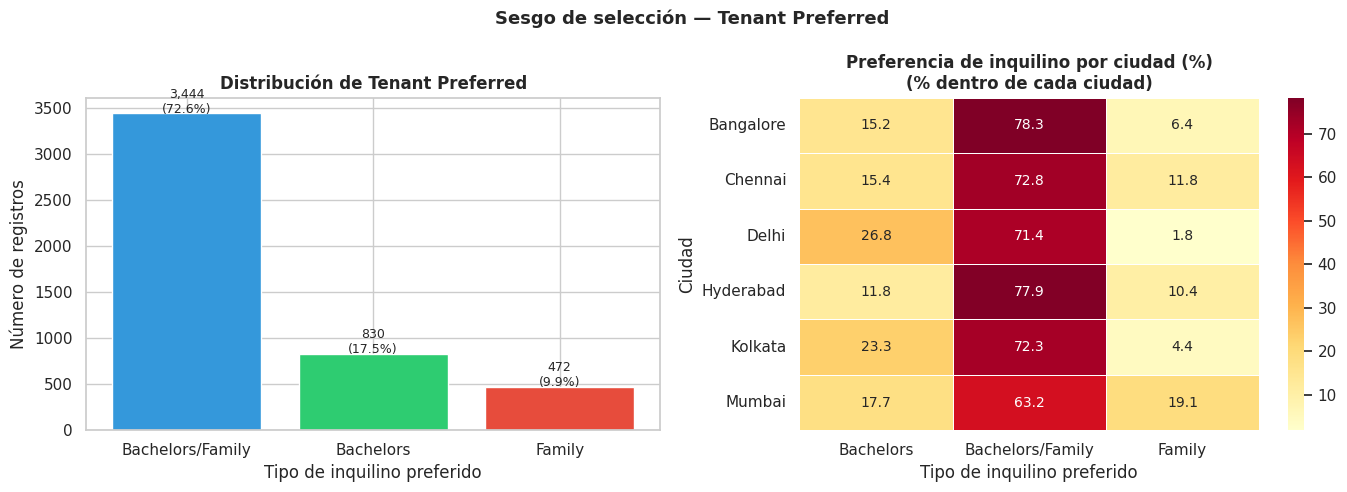

In [ ]:
# SESGO DE SELECCIÓN: Tenant Preferred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución general de Tenant Preferred
tenant_counts = df_raw['Tenant Preferred'].value_counts()
colors_tenant = ['#3498db', '#2ecc71', '#e74c3c']
axes[0].bar(tenant_counts.index, tenant_counts.values,
            color=colors_tenant, edgecolor='white')
axes[0].set_title('Distribución de Tenant Preferred', fontweight='bold')
axes[0].set_xlabel('Tipo de inquilino preferido')
axes[0].set_ylabel('Número de registros')
for i, (idx, val) in enumerate(tenant_counts.items()):
    axes[0].text(i, val + 10, f'{val:,}\n({val/len(df_raw)*100:.1f}%)',
                 ha='center', fontsize=9)

# Distribución por ciudad (heatmap de proporciones)
pivot_tenant = pd.crosstab(df_raw['City'], df_raw['Tenant Preferred'],
                            normalize='index') * 100
sns.heatmap(pivot_tenant, annot=True, fmt='.1f', cmap='YlOrRd',
            ax=axes[1], linewidths=0.5, annot_kws={'size': 10})
axes[1].set_title('Preferencia de inquilino por ciudad (%)\n(% dentro de cada ciudad)',
                   fontweight='bold')
axes[1].set_xlabel('Tipo de inquilino preferido')
axes[1].set_ylabel('Ciudad')

plt.suptitle('Sesgo de selección — Tenant Preferred',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis
El conjunto de gráficos revela que la categoría dominante es la "Bachelors/Family" lo que quiere decir que la mayoría de arrendatarios no muestran interés ante un inquilino en especifico. Por su parte, el gráfico de calor demuestra que cuando se aplican restricciones, el mercado se segmenta de forma muy diferente según la región: ciudades como Dehli y Kolkata exhiben tasas de preferencia exclusiva por solteros (Bachelors) inusualmente altas (26.8% y 23.3% respectivamente), mientras que en Mumbay se inclina más hacia las familias registrando un (19.1%) pero con unos valores similares respecto a los solteros (17.7%).

---
## <span style="color:#2F749F;"><strong>2. Preprocesamiento inicial</strong></span>

Antes del análisis exploratorio, se realizan correcciones necesarias en los tipos de datos, se identifican duplicados y se extraen características de la variable temporal.

In [ ]:
# Trabajar sobre una copia
df = df_raw.copy()

# 2.1 CONVERSIÓN DE TIPO: Posted On → datetime
df['Posted On'] = pd.to_datetime(df['Posted On'])
print("'Posted On' convertida a datetime.")
print(f"   Rango temporal: {df['Posted On'].min().date()} → {df['Posted On'].max().date()}")

# 2.2 EXTRACCIÓN DE CARACTERÍSTICAS TEMPORALES
df['Año']    = df['Posted On'].dt.year
df['Mes']    = df['Posted On'].dt.month
df['Nombre_Mes'] = df['Posted On'].dt.strftime('%b')

# 2.3 DUPLICADOS
n_dup = df.duplicated().sum()
print(f"\n Registros duplicados: {n_dup}")
if n_dup > 0:
    df = df.drop_duplicates()
    print(f"   Eliminados. Nuevo tamaño: {df.shape[0]:,}")

# 2.4 EXTRACCIÓN DE PISO (Floor)
def extraer_piso(valor):
    if pd.isnull(valor):
        return np.nan
    val_lower = str(valor).lower()
    if 'ground' in val_lower:
        return 0
    if 'basement' in val_lower or 'lower' in val_lower:
        return -1
    try:
        return int(str(valor).split(' ')[0])
    except:
        return np.nan

df['Piso_Num'] = df['Floor'].apply(extraer_piso)
print(f"\n Variable 'Piso_Num' creada.")
print(df['Piso_Num'].value_counts().head(8))

'Posted On' convertida a datetime.
   Rango temporal: 2022-04-13 → 2022-07-11

 Registros duplicados: 0

 Variable 'Piso_Num' creada.
Piso_Num
1    1161
2     945
0     927
3     512
4     272
5     164
6      93
7      74
Name: count, dtype: int64


In [ ]:
# 2.5 RESUMEN DE VALORES FALTANTES
faltantes = df.isnull().sum()
pct = (faltantes / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'Faltantes': faltantes, 'Porcentaje (%)': pct})
resumen_nulos = resumen_nulos[resumen_nulos['Faltantes'] > 0]

if resumen_nulos.empty:
    print("No se encontraron valores faltantes en el dataset.")
else:
    print("Variables con valores faltantes:")
    print(resumen_nulos)

No se encontraron valores faltantes en el dataset.


---
## <span style="color:#2F749F;"><strong>3. Análisis Exploratorio de Datos (EDA)</strong></span>

El EDA sigue tres niveles progresivos: **univariado**, **bivariado** y **multivariado** ). En cada sección se interpretan los resultados en función de la pregunta de investigación.

### <span style="color:#1a7a4a;"><strong>3.1 Análisis Univariado</strong></span>
**Objetivo:** Describir la distribución individual de las variables más relevantes para la pregunta de investigación. Se seleccionan `Rent` como variable objetivo, `Size`, `BHK` y `Bathroom` por ser las características físicas principales del inmueble, y `City` y `Furnishing Status` por ser los factores contextuales con mayor capacidad esperada de diferenciación de precios según la literatura de mercados inmobiliarios. Variables como `Area Locality` y `Point of Contact` se excluyen del análisis univariado por su alta cardinalidad o nula relevancia analítica para la pregunta planteada.

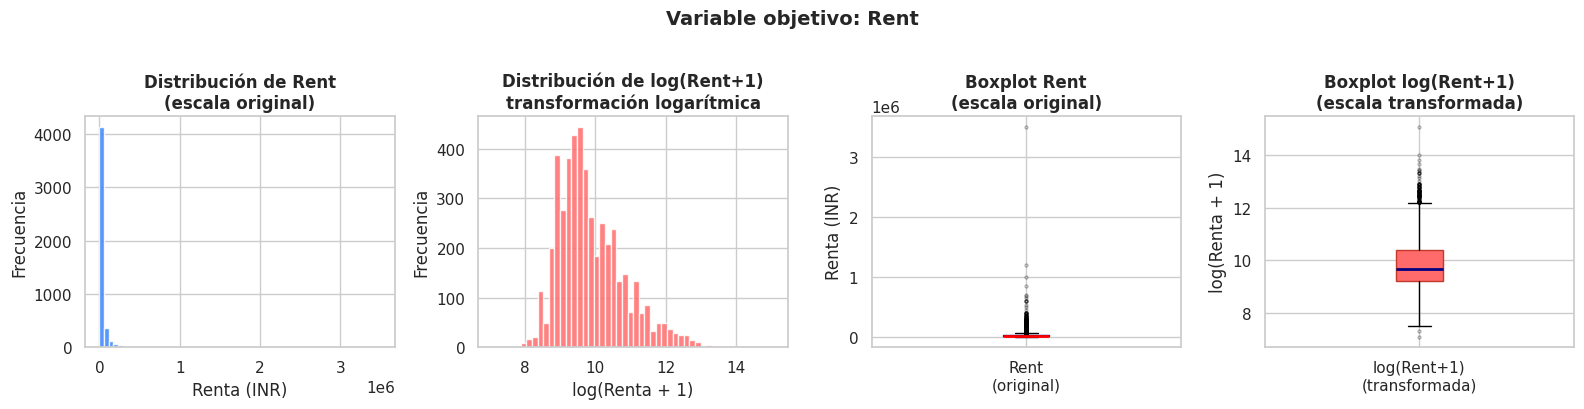


 Estadísticas descriptivas de Rent:
count        4,746
mean        34,993
std         78,106
min          1,200
25%         10,000
50%         16,000
75%         33,000
max      3,500,000
Name: Rent, dtype: object

Asimetría (skewness): 21.410
Curtosis (kurtosis):  841.108


In [ ]:
# VARIABLE OBJETIVO: Rent
fig = plt.figure(figsize=(16, 4))

# Subplot 1: histograma original
ax1 = fig.add_subplot(1, 4, 1)
ax1.hist(df['Rent'], bins=60, color='#3a86ff',
         edgecolor='white', alpha=0.85)
ax1.set_title('Distribución de Rent\n(escala original)', fontweight='bold')
ax1.set_xlabel('Renta (INR)')
ax1.set_ylabel('Frecuencia')

# Subplot 2: histograma transformado
ax2 = fig.add_subplot(1, 4, 2)
ax2.hist(np.log1p(df['Rent']), bins=50, color='#ff6b6b',
         edgecolor='white', alpha=0.85)
ax2.set_title('Distribución de log(Rent+1)\ntransformación logarítmica',
              fontweight='bold')
ax2.set_xlabel('log(Renta + 1)')
ax2.set_ylabel('Frecuencia')

# Subplot 3: boxplot Rent original (su propia escala)
ax3 = fig.add_subplot(1, 4, 3)
ax3.boxplot(df['Rent'], patch_artist=True,
            boxprops=dict(facecolor='#8ecae6', color='navy'),
            medianprops=dict(color='red', linewidth=2),
            flierprops=dict(marker='o', markersize=2,
                            alpha=0.3, color='gray'))
ax3.set_title('Boxplot Rent\n(escala original)', fontweight='bold')
ax3.set_ylabel('Renta (INR)')
ax3.set_xticks([1])
ax3.set_xticklabels(['Rent\n(original)'])

# Subplot 4: boxplot log(Rent+1) (su propia escala)
ax4 = fig.add_subplot(1, 4, 4)
ax4.boxplot(np.log1p(df['Rent']), patch_artist=True,
            boxprops=dict(facecolor='#ff6b6b', color='#c0392b'),
            medianprops=dict(color='navy', linewidth=2),
            flierprops=dict(marker='o', markersize=2,
                            alpha=0.3, color='gray'))
ax4.set_title('Boxplot log(Rent+1)\n(escala transformada)', fontweight='bold')
ax4.set_ylabel('log(Renta + 1)')
ax4.set_xticks([1])
ax4.set_xticklabels(['log(Rent+1)\n(transformada)'])

plt.suptitle('Variable objetivo: Rent', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
# Estadísticas descriptivas
print("\n Estadísticas descriptivas de Rent:")
print(df['Rent'].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nAsimetría (skewness): {df['Rent'].skew():.3f}")
print(f"Curtosis (kurtosis):  {df['Rent'].kurtosis():.3f}")


### Análisis:

La variable Rent presenta una distribución fuertemente asimétrica (skewness = 21.41), donde la gran mayoría de propiedades se concentra entre 10.000 y 33.000 INR, pero un pequeño grupo de inmuebles de lujo alcanza los 3.500.000 INR, generando una cola derecha que hace ilegible la distribución en escala original.

Para corregir este comportamiento se aplicó la transformación log(x + 1) sobre cada valor de renta. Esta función reduce el sesgo al comprimir los valores extremos: la diferencia entre 16.000 y 3.500.000 INR, que en escala original es de más de 3,4 millones de unidades, queda reducida a apenas 5,4 unidades en escala logarítmica. El resultado es una reducción del coeficiente de asimetría de 21.41 a 0.91

El boxplot comparativo evidencia el efecto de esta transformación sobre la estructura interna del dato: en la escala original la caja es prácticamente invisible frente a los valores extremos, mientras que en la escala transformada los cuartiles son legibles y la mediana queda correctamente posicionada. Ambas distribuciones conservan outliers, confirmando que los valores atípicos son propiedades de lujo reales y no errores de captura.

In [ ]:
# TEST DE NORMALIDAD PARA Rent
np.random.seed(42)
muestra = df['Rent'].dropna().sample(500)

stat_ks, p_ks = kstest(muestra, 'norm',
                        args=(muestra.mean(), muestra.std()))

stat_sw, p_sw = shapiro(muestra)

print("="*55)
print("  Test de normalidad sobre Rent (muestra n=500)")
print("="*55)
print(f"  Kolmogorov-Smirnov : estadístico={stat_ks:.4f}, p={p_ks:.4e}")
print(f"  Shapiro-Wilk        : estadístico={stat_sw:.4f}, p={p_sw:.4e}")
print("="*55)


  Test de normalidad sobre Rent (muestra n=500)
  Kolmogorov-Smirnov : estadístico=0.3229, p=6.8764e-47
  Shapiro-Wilk        : estadístico=0.3722, p=3.4462e-38


### Análisis
Los resultados de ambas pruebas rechazan la hipótesis nula de normalidad con p-valores extremadamente pequeños (KS: 6.87e-47, SW: 3.45e-38), lo que era esperable dado el comportamiento visual observado en el histograma. La distribución de `Rent` presenta una asimetría positiva marcada, característica típica de variables de precio donde unos pocos valores extremos (las propiedades de lujo) jalan la cola hacia la derecha. Esta conclusión justifica el uso de la transformación logarítmica en los análisis subsiguientes y el uso de Spearman en lugar de Pearson para las correlaciones.

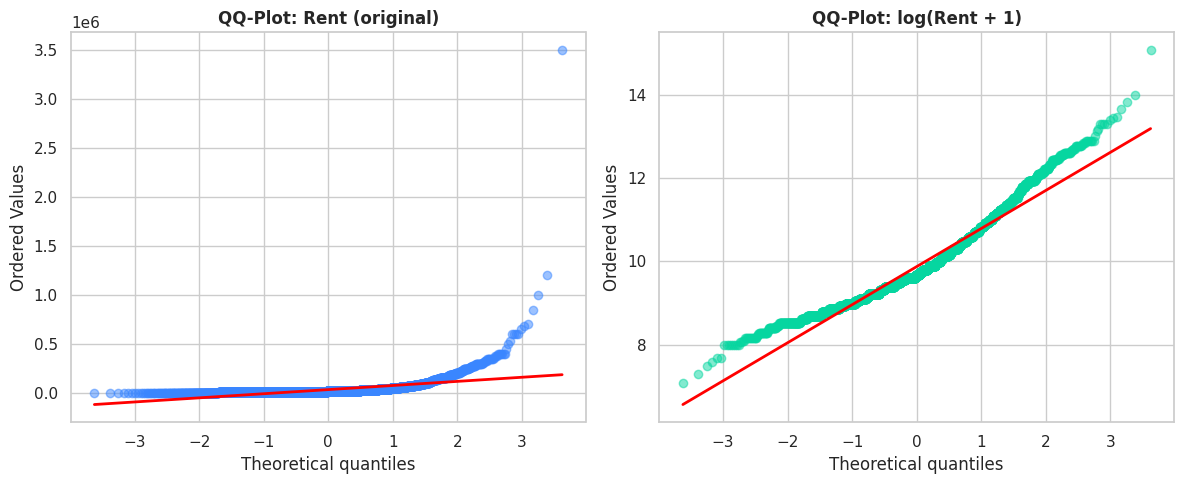


El QQ-plot confirma la fuerte desviación de normalidad en escala original.
   La transformación logarítmica acerca la distribución a la normal.


In [ ]:
#QQ-PLOT para confirmar asimetría
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# QQ-plot Rent original
stats.probplot(df['Rent'].dropna(), dist='norm', plot=axes[0])
axes[0].set_title('QQ-Plot: Rent (original)', fontweight='bold')
axes[0].get_lines()[0].set(color='#3a86ff', alpha=0.5)
axes[0].get_lines()[1].set(color='red', linewidth=2)

# QQ-plot log(Rent)
stats.probplot(np.log1p(df['Rent'].dropna()), dist='norm', plot=axes[1])
axes[1].set_title('QQ-Plot: log(Rent + 1)', fontweight='bold')
axes[1].get_lines()[0].set(color='#06d6a0', alpha=0.5)
axes[1].get_lines()[1].set(color='red', linewidth=2)

plt.tight_layout()
plt.show()
print("\nEl QQ-plot confirma la fuerte desviación de normalidad en escala original.")
print("   La transformación logarítmica acerca la distribución a la normal.")


Size:
   Media: 967.49 | Mediana: 850.00 | Skewness: 2.300

BHK:
   Media: 2.08 | Mediana: 2.00 | Skewness: 0.599

Bathroom:
   Media: 1.97 | Mediana: 2.00 | Skewness: 1.273


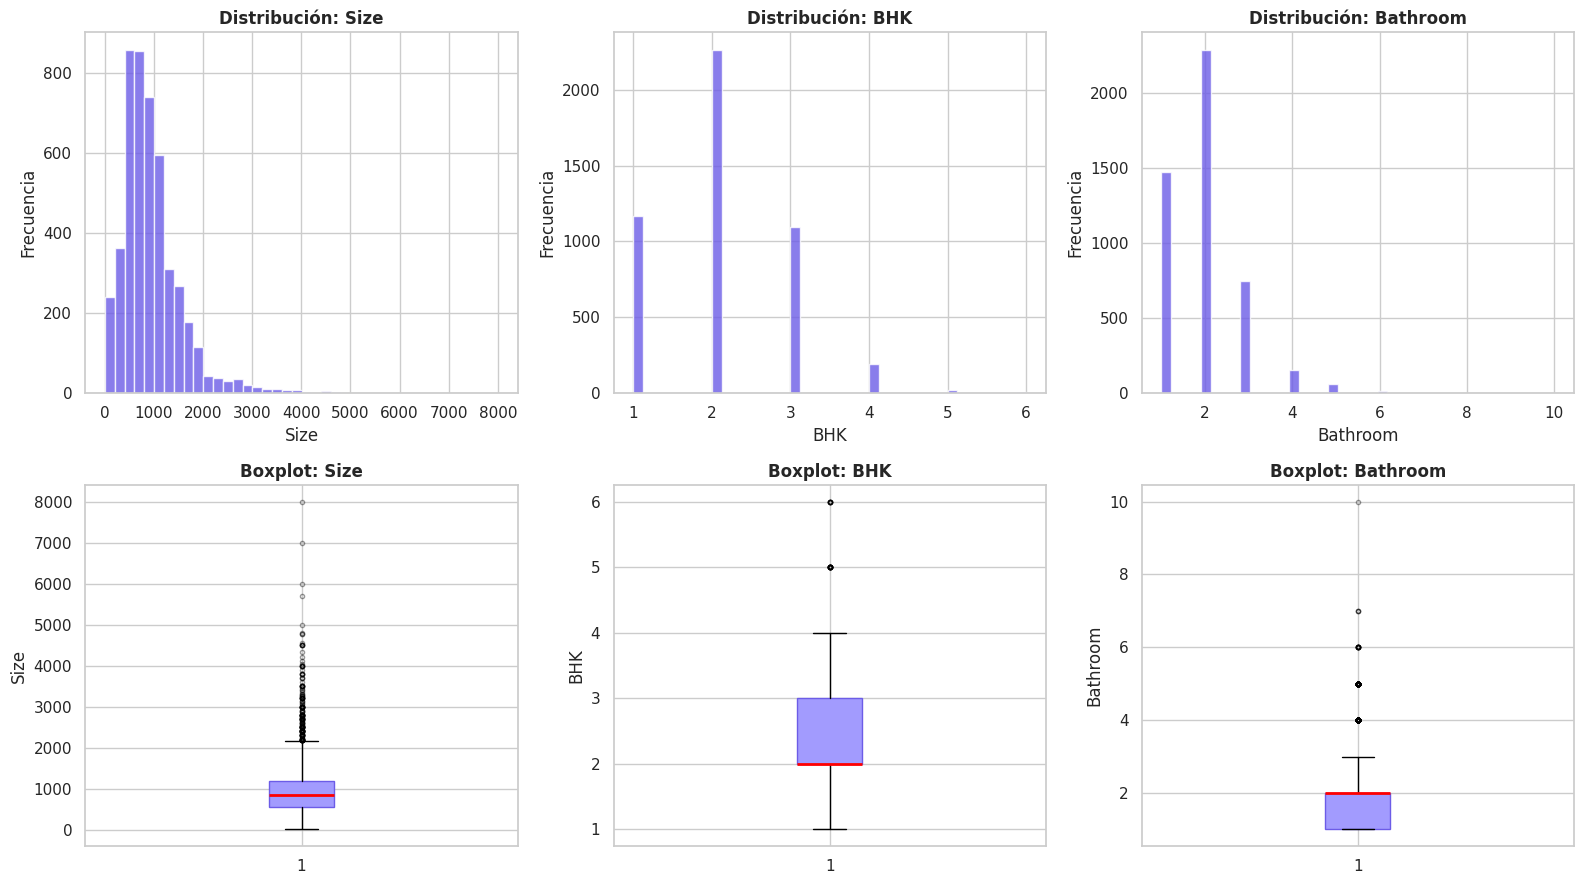

In [ ]:
# VARIABLES NUMÉRICAS: Size, BHK, Bathroom
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
vars_num = ['Size', 'BHK', 'Bathroom']

for i, var in enumerate(vars_num):
    data = df[var].dropna()

    # Histograma
    axes[0, i].hist(data, bins=40, color='#6c5ce7', edgecolor='white', alpha=0.8)
    axes[0, i].set_title(f'Distribución: {var}', fontweight='bold')
    axes[0, i].set_xlabel(var)
    axes[0, i].set_ylabel('Frecuencia')

    # Boxplot
    axes[1, i].boxplot(data, patch_artist=True,
                       boxprops=dict(facecolor='#a29bfe', color='#6c5ce7'),
                       medianprops=dict(color='red', linewidth=2),
                       flierprops=dict(marker='o', color='#fd79a8', alpha=0.4, markersize=3))
    axes[1, i].set_title(f'Boxplot: {var}', fontweight='bold')
    axes[1, i].set_ylabel(var)

    # Estadísticas en consola
    print(f"\n{var}:")
    print(f"   Media: {data.mean():.2f} | Mediana: {data.median():.2f} | "
          f"Skewness: {data.skew():.3f}")

plt.tight_layout()
plt.show()

### Análisis
 `BHK` y `Bathroom` muestran un estándar consolidado: la mayoría de propiedades tienen 2 habitaciones y 2 baños, con caída rápida hacia configuraciones de lujo. `Size` en cambio presenta fuerte asimetría positiva — la mayoría de inmuebles se concentra entre 500 y 1.200 pies cuadrados (mediana: 850 aprox), pero una cola de valores extremos se extiende hasta los 8.000 pies cuadrados, correspondiente a residencias excepcionales. Este comportamiento justifica la aplicación de la transformación logarítmica (`log_Size`) en los análisis posteriores para estabilizar la varianza.

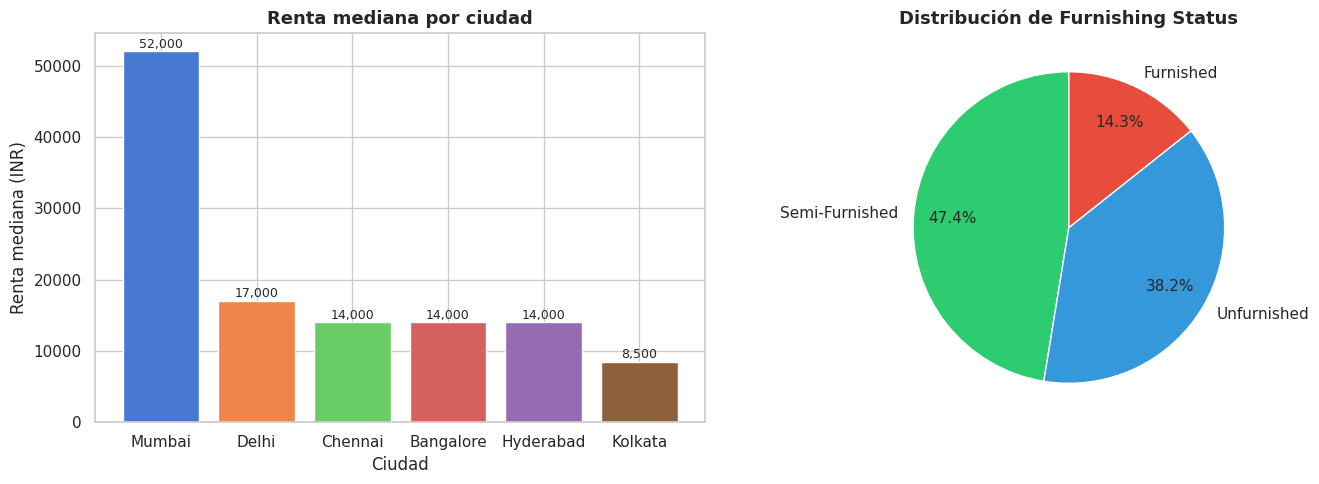


Renta mediana por ciudad (INR):
City
Mumbai       52,000
Delhi        17,000
Chennai      14,000
Bangalore    14,000
Hyderabad    14,000
Kolkata       8,500

Frecuencias — Furnishing Status:
Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680


In [ ]:
# VARIABLES CATEGÓRICAS: Rent mediana por Ciudad y Furnishing Status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Rent mediano por ciudad
rent_ciudad = df.groupby('City')['Rent'].median().sort_values(ascending=False)
bars = axes[0].bar(rent_ciudad.index, rent_ciudad.values,
                   color=sns.color_palette('muted', len(rent_ciudad)), edgecolor='white')
axes[0].set_title('Renta mediana por ciudad', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Renta mediana (INR)')
for bar, val in zip(bars, rent_ciudad.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', va='bottom', fontsize=9)

# Furnishing Status
furn_counts = df['Furnishing Status'].value_counts()
colors_furn = ['#2ecc71', '#3498db', '#e74c3c']
wedges, texts, autotexts = axes[1].pie(furn_counts.values, labels=furn_counts.index,
                                        autopct='%1.1f%%', colors=colors_furn,
                                        startangle=90, pctdistance=0.75)
for at in autotexts:
    at.set_fontsize(11)
axes[1].set_title('Distribución de Furnishing Status', fontweight='bold', fontsize=13)

plt.tight_layout()
plt.show()

print("\nRenta mediana por ciudad (INR):")
print(rent_ciudad.apply(lambda x: f"{x:,.0f}").to_string())
print("\nFrecuencias — Furnishing Status:")
print(furn_counts.to_string())

### Análisis
La renta mediana por ciudad expone una brecha extraordinaria entre mercados: Mumbai lidera con 52.000 INR, más del triple que Delhi (17.000 INR) y casi seis veces por encima de Kolkata (8.500 INR), lo que refleja la presión inmobiliaria característica de la capital financiera de India. Chennai, Bangalore e Hyderabad convergen en 14.000 INR, sugiriendo dinámicas de mercado similares. Respecto al amueblado, el mercado se inclina hacia opciones Semi-Furnished (47.4%) y Unfurnished (38.2%), siendo las propiedades Furnished una minoría del 14.3% — lo que anticipa que el nivel de amueblado podría ser un diferenciador.

### <span style="color:#1a7a4a;"><strong>3.2 Análisis Bivariado</strong></span>
**Objetivo:** Cuantificar y visualizar la relación entre el precio de renta y cada una de las variables explicativas, usando el método de correlación adecuado para cada tipo de par de variables.

### Nota metodológica
Las variables `BHK` y `Bathroom` son numéricas discretas de naturaleza ordinal — existe un orden natural entre sus categorías. Para el análisis de correlación se utiliza el coeficiente de Spearman, que mide relaciones monótonas y es apropiado tanto para variables continuas como para variables ordinales discretas, a diferencia de Pearson que asume continuidad y normalidad. Esta decisión es coherente con el rechazo de normalidad demostrado para `Rent` en la sección 3.1.

In [ ]:
# 3.2.1 CORRELACIÓN Pearson y Spearman: Rent vs numéricas
vars_num_analisis = ['Size', 'BHK', 'Bathroom']

print("="*65)
print(f"  {'Variable':<15} {'Pearson r':>12} {'p-valor':>12} {'Spearman ρ':>12} {'p-valor':>12}")
print("="*65)
for var in vars_num_analisis:
    sub = df[['Rent', var]].dropna()
    r_p, p_p = pearsonr(sub['Rent'], sub[var])
    r_s, p_s = spearmanr(sub['Rent'], sub[var])
    print(f"  {var:<15} {r_p:>12.4f} {p_p:>12.4e} {r_s:>12.4f} {p_s:>12.4e}")
print("="*65)
print("\n Spearman es más apropiado dado que Rent no es normal.")
print("   Un p-valor < 0.05 indica correlación estadísticamente significativa.")

  Variable           Pearson r      p-valor   Spearman ρ      p-valor
  Size                  0.4136  1.6909e-195       0.5214   0.0000e+00
  BHK                   0.3697  1.2069e-153       0.5684   0.0000e+00
  Bathroom              0.4412  2.4419e-225       0.6630   0.0000e+00

 Spearman es más apropiado dado que Rent no es normal.
   Un p-valor < 0.05 indica correlación estadísticamente significativa.


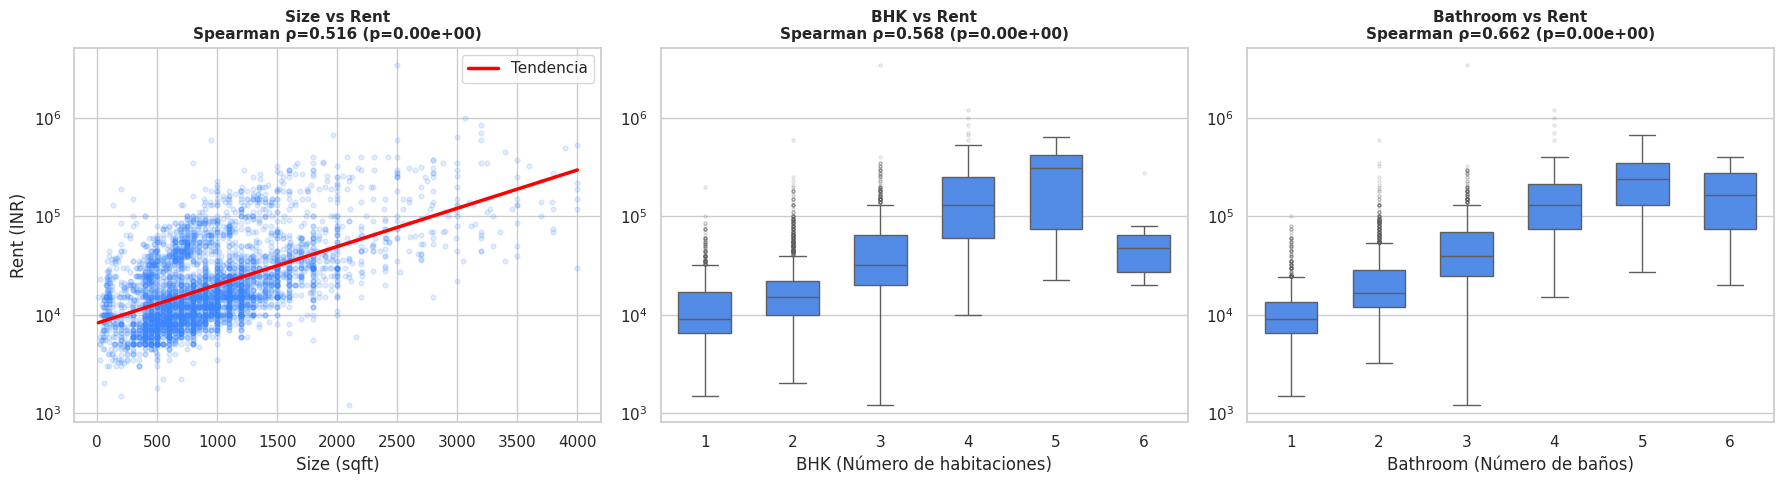

In [ ]:
# Visualización: Scatterplots Rent vs numéricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

var_1 = 'Size'
sub_1 = df[[var_1, 'Rent']].dropna()

sub_1 = sub_1[sub_1[var_1] <= 4000]

axes[0].scatter(sub_1[var_1], sub_1['Rent'], alpha=0.15, s=12, color='#3a86ff')

z = np.polyfit(sub_1[var_1], np.log(sub_1['Rent']), 1)
p = np.poly1d(z)
xline = np.linspace(sub_1[var_1].min(), sub_1[var_1].max(), 100)
axes[0].plot(xline, np.exp(p(xline)), color='red', linewidth=2.5, label='Tendencia')

r_s, p_s = spearmanr(sub_1[var_1], sub_1['Rent'])
axes[0].set_title(f'{var_1} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[0].set_xlabel(f'{var_1} (sqft)')
axes[0].set_ylabel('Rent (INR)')
axes[0].set_yscale('log')
axes[0].legend()

var_2 = 'BHK'
sub_2 = df[[var_2, 'Rent']].dropna()
sub_2 = sub_2[sub_2[var_2] <= 6]
sub_2['BHK'] = sub_2['BHK'].astype(int)


sns.boxplot(data=sub_2, x=var_2, y='Rent', ax=axes[1], color='#3a86ff', width=0.6, flierprops={'markersize': 2, 'alpha': 0.2})

r_s, p_s = spearmanr(sub_2[var_2], sub_2['Rent'])
axes[1].set_title(f'{var_2} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[1].set_xlabel('BHK (Número de habitaciones)')
axes[1].set_ylabel('')
axes[1].set_yscale('log')

var_3 = 'Bathroom'
sub_3 = df[[var_3, 'Rent']].dropna()
sub_3 = sub_3[sub_3[var_3] <= 6]

sns.boxplot(data=sub_3, x=var_3, y='Rent', ax=axes[2], color='#3a86ff', width=0.6, flierprops={'markersize': 2, 'alpha': 0.2})

r_s, p_s = spearmanr(sub_3[var_3], sub_3['Rent'])
axes[2].set_title(f'{var_3} vs Rent\nSpearman ρ={r_s:.3f} (p={p_s:.2e})', fontweight='bold', fontsize=11)
axes[2].set_xlabel('Bathroom (Número de baños)')
axes[2].set_ylabel('')
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

### Análisis
Las tres variables físicas presentan correlación positiva y estadísticamente significativa con `Rent` (p ≈ 0.00). `Bathroom` es el predictor individual más robusto (ρ = 0.662), seguido de `BHK` (ρ = 0.568) y `Size` (ρ = 0.516). Los gráficos de `BHK` y `Bathroom` muestran un comportamiento escalonado donde la renta mediana se duplica o triplica con cada unidad adicional, aunque ambas variables presentan una caída anómala en la categoría de 6 unidades explicable por escasez muestral en el extremo superior. La dispersión en `Size vs Rent` refleja la influencia de factores externos como la ubicación, lo que anticipa la necesidad de un análisis multivariado para capturar estas interacciones.

In [ ]:
# 3.2.2 PRUEBA KRUSKAL-WALLIS: Rent vs categóricas
vars_cat = ['City', 'Furnishing Status', 'Tenant Preferred']

print("="*60)
print(f"  {'Variable':<22} {'H-estadístico':>16} {'p-valor':>12}")
print("="*60)
for var in vars_cat:
    grupos = [group['Rent'].values for _, group in df.groupby(var)]
    h_stat, p_val = kruskal(*grupos)
    significativo = "Significativo" if p_val < 0.05 else " No significativo"
    print(f"  {var:<22} {h_stat:>16.3f} {p_val:>12.4e}  {significativo}")
print("="*60)
print("\n Un p < 0.05 indica que la variable categórica influye en el precio de renta.")

  Variable                  H-estadístico      p-valor
  City                           1613.674   0.0000e+00  Significativo
  Furnishing Status               423.495   1.0948e-92  Significativo
  Tenant Preferred                177.237   3.2612e-39  Significativo

 Un p < 0.05 indica que la variable categórica influye en el precio de renta.


### Análisis
Las tres variables categóricas muestran un efecto estadísticamente significativo sobre `Rent` (p < 0.05 en todos los casos). `City` presenta el estadístico H más alto (1613.674), lo que indica que la ubicación geográfica es el factor categórico con mayor capacidad diferenciadora del precio — consistente con la brecha de 6x observada entre Mumbai y Kolkata en el análisis univariado. `Furnishing Status` ocupa el segundo lugar (H = 423.495), confirmando que el nivel de amueblado tiene un impacto real y no aleatorio sobre el precio. `Tenant Preferred` aunque significativo, registra el H más bajo (177.237), sugiriendo que su influencia sobre el precio es menor comparada con las otras dos variables — lo que refuerza la decisión ética de tratarla como variable descriptiva y no predictiva.

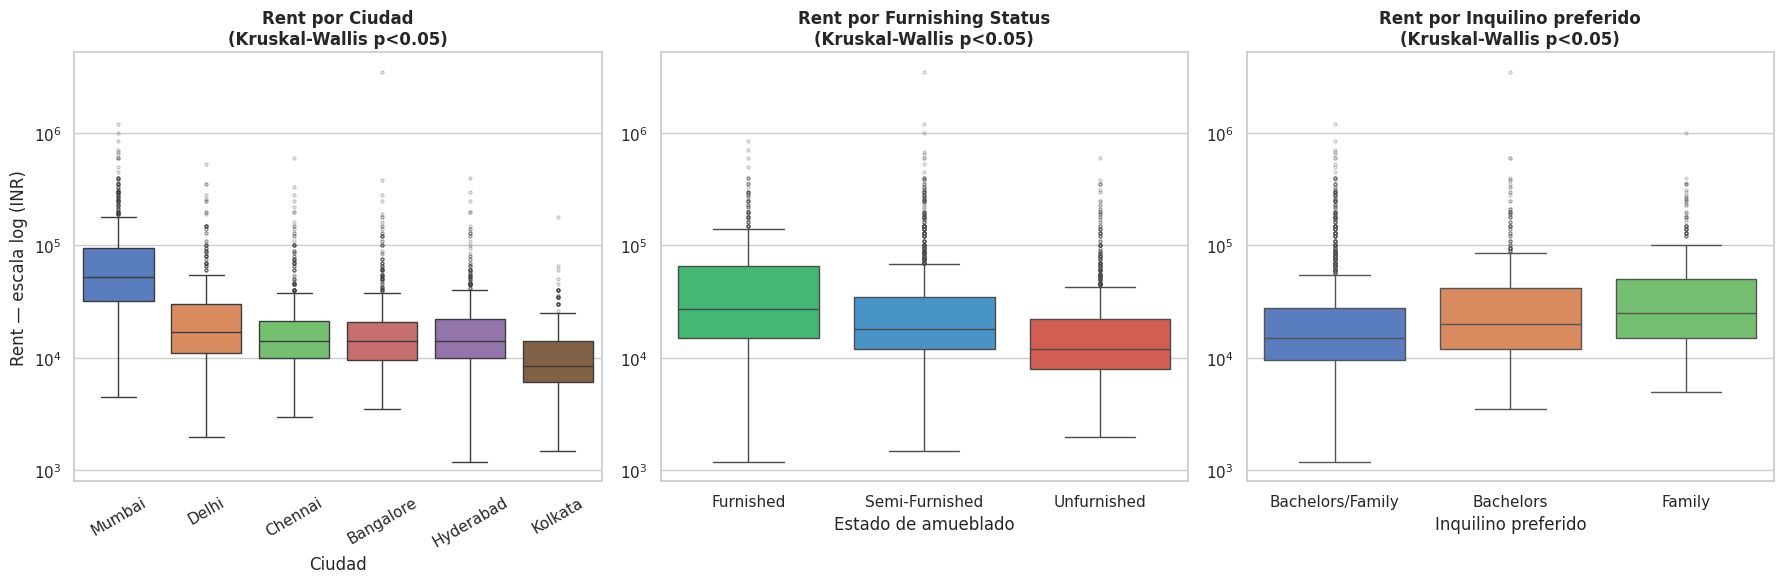

In [ ]:
# Boxplots: Rent vs categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
palette = sns.color_palette('muted', 10)

# Ciudad
order_city = df.groupby('City')['Rent'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='City', y='Rent', order=order_city,
            palette=palette[:6], ax=axes[0], flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[0].set_yscale('log')
axes[0].set_title('Rent por Ciudad\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[0].set_xlabel('Ciudad')
axes[0].set_ylabel('Rent — escala log (INR)')
axes[0].tick_params(axis='x', rotation=30)

# Furnishing Status
order_furn = ['Furnished', 'Semi-Furnished', 'Unfurnished']
sns.boxplot(data=df, x='Furnishing Status', y='Rent', order=order_furn,
            palette=['#2ecc71','#3498db','#e74c3c'], ax=axes[1],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[1].set_yscale('log')
axes[1].set_title('Rent por Furnishing Status\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[1].set_xlabel('Estado de amueblado')
axes[1].set_ylabel('')

# Tenant Preferred
sns.boxplot(data=df, x='Tenant Preferred', y='Rent',
            palette=palette[:3], ax=axes[2],
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
axes[2].set_yscale('log')
axes[2].set_title('Rent por Inquilino preferido\n(Kruskal-Wallis p<0.05)', fontweight='bold')
axes[2].set_xlabel('Inquilino preferido')
axes[2].set_ylabel('')

plt.tight_layout()
plt.show()

### Análisis
Los boxplots confirman visualmente lo que Kruskal-Wallis indicó estadísticamente. La ciudad es el factor más disruptivo: Mumbai lidera con una mediana de 50.000 INR, superando incluso los terceros cuartiles de las demás ciudades, mientras Kolkata representa el mercado más económico con una mediana inferior a 10.000 INR. El amueblado sigue una jerarquía lineal descendente — Furnished (~ 25.000 INR), Semi-Furnished (~ 18.000 INR) y Unfurnished (~12.000 INR) — lo que sugiere que cada escalón de amueblado representa un segmento de mercado diferenciado. Finalmente, `Tenant Preferred` revela una prima por estabilidad: los contratos exclusivos para Family alcanzan medianas de ~25.000 INR frente a ~15.000 INR de las opciones flexibles, aunque la amplia superposición entre categorías indica que esta variable actúa como modulador secundario del precio, no como determinante principal.

In [ ]:
# 3.2.3 CHI-CUADRADO: relación entre categóricas
# ¿La ciudad está asociada con el estado de amueblado?
tabla_contingencia = pd.crosstab(df['City'], df['Furnishing Status'])
chi2, p_chi, dof, expected = chi2_contingency(tabla_contingencia)

print("="*55)
print("  Chi-cuadrado: City vs Furnishing Status")
print("="*55)
print(f"  Chi² = {chi2:.4f} | gl = {dof} | p = {p_chi:.4e}")
if p_chi < 0.05:
    print("Existe asociación significativa entre ciudad y amueblado.")
else:
    print("No se evidencia asociación significativa.")
print()
print("Tabla de contingencia (frecuencias observadas):")
print(tabla_contingencia.to_string())

  Chi-cuadrado: City vs Furnishing Status
  Chi² = 351.5571 | gl = 10 | p = 1.8618e-69
Existe asociación significativa entre ciudad y amueblado.

Tabla de contingencia (frecuencias observadas):
Furnishing Status  Furnished  Semi-Furnished  Unfurnished
City                                                     
Bangalore                 91             584          211
Chennai                   81             448          362
Delhi                     97             278          230
Hyderabad                111             402          355
Kolkata                   61             142          321
Mumbai                   239             397          336


### <span style="color:#1a7a4a;"><strong>3.3 Análisis Multivariado</strong></span>
**Objetivo:** Explorar las relaciones simultáneas entre múltiples variables para identificar patrones de agrupación, interacciones y la estructura latente de los datos.

Dado que el dataset cuenta únicamente con dos variables verdaderamente
continuas (`Rent` y `Size`), no se justifica la aplicación de PCA,
que requiere un espacio de alta dimensionalidad para ser informativo.
El análisis multivariado se realiza mediante correlaciones y
visualizaciones de interacción entre variables.

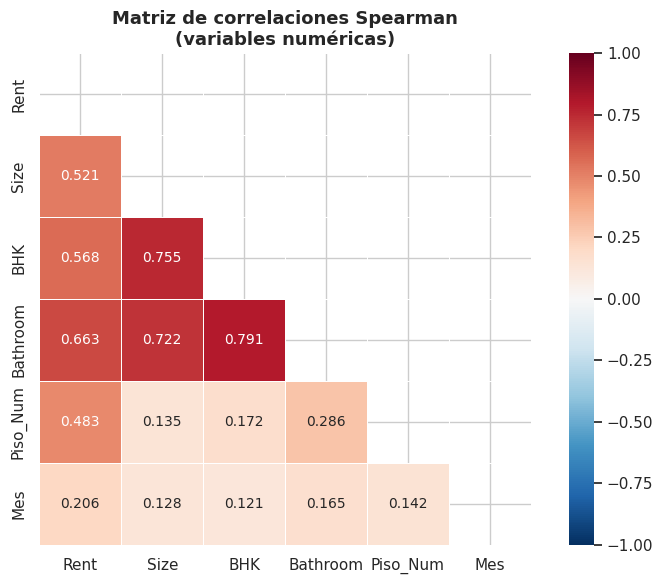

In [ ]:
# 3.3.1 MAPA DE CORRELACIONES (Spearman)
vars_num_corr = ['Rent', 'Size', 'BHK', 'Bathroom', 'Piso_Num', 'Mes']
corr_matrix = df[vars_num_corr].dropna().corr(method='spearman')

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, mask=mask,
            ax=ax, linewidths=0.5, square=True,
            annot_kws={'size': 10})
ax.set_title('Matriz de correlaciones Spearman\n(variables numéricas)',
             fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

### Análisis
La matriz de Spearman revela que `Bathroom` (ρ = 0.663), `BHK` (ρ = 0.568) y `Size` (ρ = 0.521) son los predictores más asociados con `Rent`, mientras `Piso_Num` muestra una correlación moderada (ρ = 0.483) y `Mes` resulta prácticamente irrelevante (ρ < 0.21), descartando cualquier estacionalidad en el precio. El hallazgo más importante es la multicolinealidad entre las variables estructurales: `BHK`, `Bathroom` y `Size` presentan correlaciones cruzadas entre 0.722 y 0.791, indicando que comparten gran parte de su varianza explicativa. Esto implica que en etapas de modelado no deberían incluirse las tres simultáneamente sin un tratamiento previo — como PCA o selección de variables — para evitar redundancia informativa.

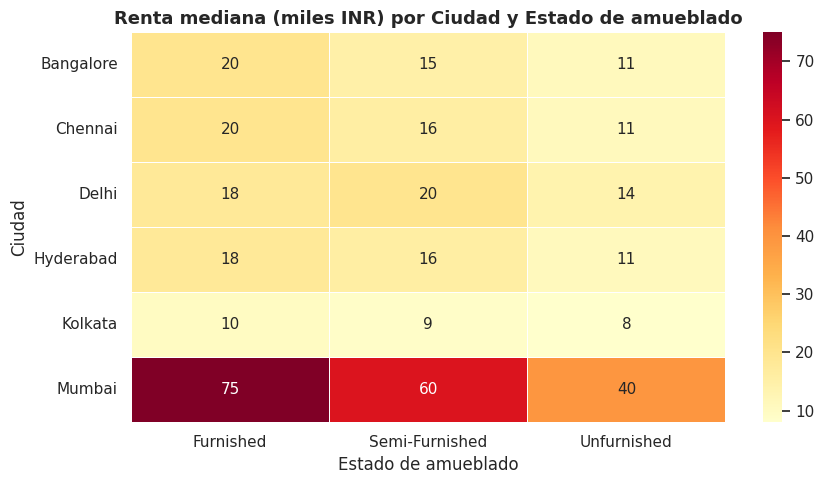

In [ ]:
#3.3.2 PRECIO PROMEDIO POR CIUDAD Y AMUEBLADO (Heatmap)
pivot = df.groupby(['City', 'Furnishing Status'])['Rent'].median().unstack()
pivot = pivot.reindex(columns=['Furnished', 'Semi-Furnished', 'Unfurnished'])

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot/1000, annot=True, fmt='.0f', cmap='YlOrRd',
            ax=ax, linewidths=0.5,
            annot_kws={'size': 11})
ax.set_title('Renta mediana (miles INR) por Ciudad y Estado de amueblado',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Estado de amueblado')
ax.set_ylabel('Ciudad')
plt.tight_layout()
plt.show()


### Análisis
Se realizaron dos hallazgos clave. Primero, Mumbai opera en una escala de precios completamente aislada: su renta mediana Unfurnished (40.000 INR) supera la opción Furnished de prácticamente cualquier otra ciudad, confirmando que la ubicación geográfica supera al amueblado como determinante del precio. Segundo, la prima por amueblado no es uniforme — en Kolkata la diferencia entre Unfurnished y Furnished es de apenas 2.000 INR, mientras que en Mumbai escala a 35.000 INR, lo que indica que el retorno de inversión por equipamiento interno está directamente condicionado a la plusvalía del mercado local. El resto de ciudades (Bangalore, Chennai, Delhi, Hyderabad, Kolkata) convergen en un rango estrecho de 8.000 a 20.000 INR independientemente del amueblado, sugiriendo que en mercados menos premium la ubicación y el amueblado tienen un efecto combinado pero moderado sobre el precio.

---
## <span style="color:#2F749F;"><strong>4. Detección de datos atípicos (Outliers)</strong></span>

Se aplican tres niveles de detección: **gráfico** (boxplot, dispersión), **estadístico** (IQR y Z-score) y **aprendizaje no supervisado** (Isolation Forest y Local Outlier Factor). La variable de interés principal es `Rent`, complementada con `Size`.

In [ ]:
# 4.1 MÉTODO IQR
def detectar_outliers_iqr(serie, nombre, k=1.5):
    Q1 = serie.quantile(0.25)
    Q3 = serie.quantile(0.75)
    IQR = Q3 - Q1
    lim_inf = Q1 - k * IQR
    lim_sup = Q3 + k * IQR
    outliers = serie[(serie < lim_inf) | (serie > lim_sup)]
    print(f"  {nombre:>12} | Q1={Q1:>10,.0f} | Q3={Q3:>10,.0f} | "
          f"IQR={IQR:>10,.0f} | Límite inf={lim_inf:>10,.0f} | "
          f"Límite sup={lim_sup:>10,.0f} | Outliers={len(outliers):>4} ({len(outliers)/len(serie)*100:.1f}%)")
    return lim_inf, lim_sup, outliers.index

print("="*110)
print("  Método IQR (k=1.5)")
print("="*110)
lim_rent_inf, lim_rent_sup, idx_iqr_rent = detectar_outliers_iqr(df['Rent'].dropna(), 'Rent')
lim_size_inf, lim_size_sup, idx_iqr_size = detectar_outliers_iqr(df['Size'].dropna(), 'Size')
print("="*110)

  Método IQR (k=1.5)
          Rent | Q1=    10,000 | Q3=    33,000 | IQR=    23,000 | Límite inf=   -24,500 | Límite sup=    67,500 | Outliers= 520 (11.0%)
          Size | Q1=       550 | Q3=     1,200 | IQR=       650 | Límite inf=      -425 | Límite sup=     2,175 | Outliers= 203 (4.3%)


### Análisis
El método con k=1.5 identifica 520 outliers en `Rent` (11.0%) y 203 en `Size` (4.3%). Para `Rent`, el límite inferior negativo (-24.500 INR) no tiene interpretación real — un precio no puede ser negativo — lo que indica que la distribución está tan sesgada hacia la derecha que el método IQR no detecta outliers por debajo, solo por encima del límite superior (67.500 INR). Esto es consistente con la fuerte asimetría positiva identificada en el análisis univariado. Para `Size`, el comportamiento es análogo: el límite inferior negativo (-425 pies cuadrados) carece de sentido físico, y los 203 outliers corresponden exclusivamente a propiedades de gran superficie por encima de 2.175 pies cuadrados. En ambos casos, los valores atípicos detectados no son necesariamente errores de datos sino propiedades de segmento alto, lo que justifica una inspección más cuidadosa antes de tomar decisiones de eliminación.

In [ ]:
#  4.2 MÉTODO Z-SCORE
# Umbral estándar: |z| > 3 → atípico extremo
def detectar_outliers_zscore(serie, nombre, umbral=3.0):
    z = np.abs(stats.zscore(serie.dropna()))
    outliers_mask = z > umbral
    n_out = outliers_mask.sum()
    print(f"  {nombre:>12} | Umbral=|z|>{umbral} | "
          f"Outliers={n_out:>4} ({n_out/len(serie)*100:.1f}%)")
    return serie.dropna().index[outliers_mask]

print("="*65)
print("  Método Z-score (sobre log(Rent) para mayor robustez)")
print("="*65)
df['log_Rent'] = np.log1p(df['Rent'])
df['log_Size'] = np.log1p(df['Size'])
idx_z_rent  = detectar_outliers_zscore(df['log_Rent'], 'log(Rent)')
idx_z_size  = detectar_outliers_zscore(df['log_Size'], 'log(Size)')
print("="*65)

  Método Z-score (sobre log(Rent) para mayor robustez)
     log(Rent) | Umbral=|z|>3.0 | Outliers=  37 (0.8%)
     log(Size) | Umbral=|z|>3.0 | Outliers=  90 (1.9%)


### Análisis
El IQR es más sensible porque opera sobre la escala original sesgada, mientras que el Z-score sobre la transformación logarítmica solo marca como atípicos los valores verdaderamente extremos que ni siquiera la corrección del sesgo logra normalizar. La decisión de aplicar Z-score sobre `log(Rent)` y no sobre `Rent` directamente es debido a que, en la escala original, la asimetría inflaría artificialmente el número de outliers detectados, confundiendo valores altos pero legítimos con anomalías reales.

In [ ]:
#4.3 ISOLATION FOREST
vars_iso = ['log_Rent', 'log_Size']
df_iso = df[vars_iso].dropna()

iso = IsolationForest(n_estimators=200, contamination=0.05, random_state=42)
pred_iso = iso.fit_predict(df_iso)
idx_iso = df_iso.index[pred_iso == -1]

print(f" Isolation Forest detectó {len(idx_iso):,} outliers "
      f"({len(idx_iso)/len(df_iso)*100:.1f}% del total)")

# 4.4 LOCAL OUTLIER FACTOR
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred_lof = lof.fit_predict(df_iso)
idx_lof = df_iso.index[pred_lof == -1]

print(f" LOF detectó {len(idx_lof):,} outliers "
      f"({len(idx_lof)/len(df_iso)*100:.1f}% del total)")

#  Consenso: outliers detectados por ≥2 métodos
from collections import Counter
todos_idx = list(idx_iqr_rent) + list(idx_iso) + list(idx_lof)
conteo = Counter(todos_idx)
idx_consenso = [i for i, c in conteo.items() if c >= 2]
print(f"\n Outliers en consenso (≥2 métodos): {len(idx_consenso):,}")

 Isolation Forest detectó 238 outliers (5.0% del total)
 LOF detectó 238 outliers (5.0% del total)

 Outliers en consenso (≥2 métodos): 141


### Análisis
Ambos métodos de aprendizaje no supervisado detectan exactamente el mismo número de outliers (238, 5.0%), lo cual no es coincidencia sino consecuencia directa del parámetro `contamination=0.05` que fuerza a ambos algoritmos a marcar el 5% de los datos como atípicos. Lo relevante no es la cantidad sino el **acuerdo entre métodos**: de los 238 outliers de cada algoritmo, solo 141 son detectados por al menos dos métodos simultáneamente — lo que representa el 2.6% del dataset. Este consenso es metodológicamente más robusto que cualquier método individual, ya que un punto marcado por múltiples enfoques distintos tiene mayor evidencia de ser genuinamente atípico. La diferencia entre los 520 outliers del IQR y los 141 del consenso ilustra la importancia de no depender de un único método: el IQR sobredetecta por la asimetría de la distribución, mientras que el consenso filtra solo los casos con evidencia múltiple.

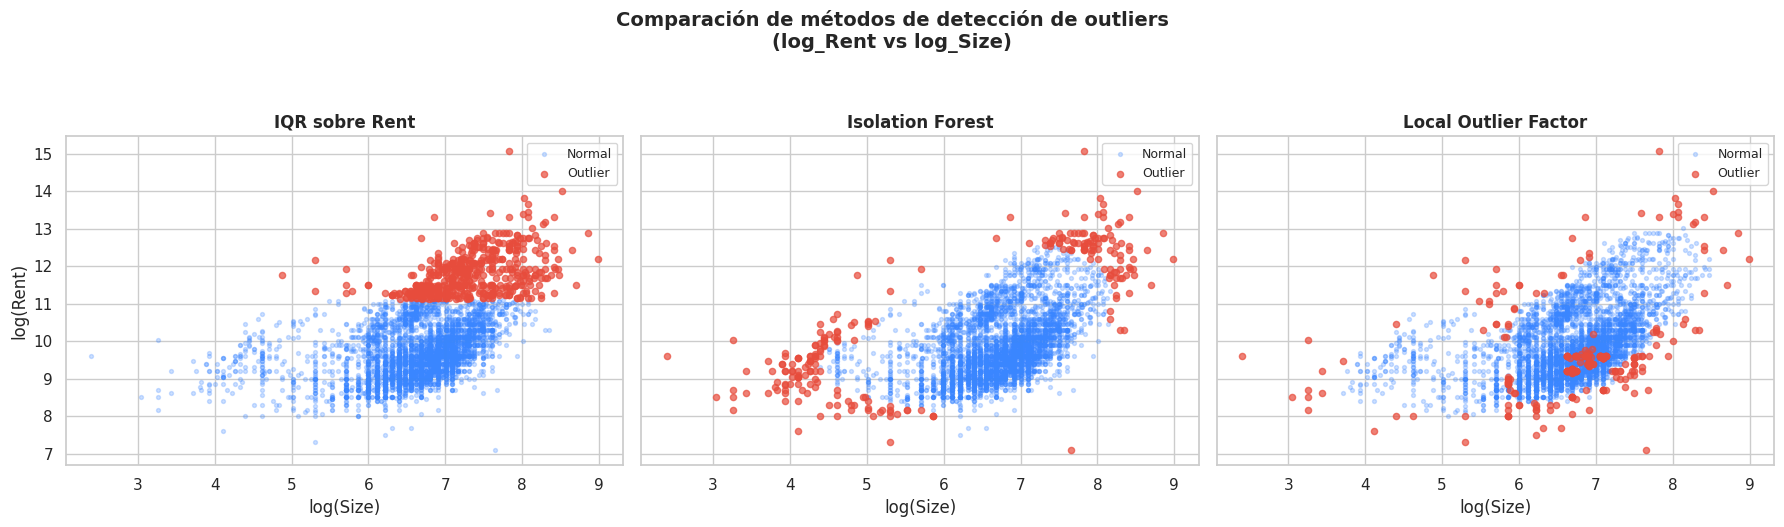

In [ ]:
# Visualización: comparación de métodos (Optimizado)
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

colores = {
    'Normal': ('#3a86ff', 0.25, 8),
    'Outlier': ('#e74c3c', 0.7, 20)
}

# IQR
mask_iqr = df_iso.index.isin(idx_iqr_rent)
for label, (color, alpha, size) in colores.items():
    m = mask_iqr if label == 'Outlier' else ~mask_iqr
    axes[0].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[0].set_title('IQR sobre Rent', fontweight='bold')
axes[0].set_xlabel('log(Size)')
axes[0].set_ylabel('log(Rent)') # El único necesario gracias a sharey=True

# Isolation Forest
mask_iso = df_iso.index.isin(idx_iso)
for label, (color, alpha, size) in colores.items():
    m = mask_iso if label == 'Outlier' else ~mask_iso
    axes[1].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[1].set_title('Isolation Forest', fontweight='bold')
axes[1].set_xlabel('log(Size)')

# LOF
mask_lof = df_iso.index.isin(idx_lof)
for label, (color, alpha, size) in colores.items():
    m = mask_lof if label == 'Outlier' else ~mask_lof
    axes[2].scatter(df_iso.loc[m, 'log_Size'], df_iso.loc[m, 'log_Rent'],
                    c=color, alpha=alpha, s=size, label=label)
axes[2].set_title('Local Outlier Factor', fontweight='bold')
axes[2].set_xlabel('log(Size)')

for ax in axes:
    ax.legend(fontsize=9, frameon=True)

plt.suptitle('Comparación de métodos de detección de outliers\n(log_Rent vs log_Size)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

### Análisis
Los tres gráficos exponen las limitaciones y fortalezas de cada enfoque. El IQR opera con un corte horizontal rígido sobre `log(Rent)`, lo que genera sobredetección en el cuadrante superior derecho: propiedades de precio alto pero con tamaños proporcionales quedan marcadas como outliers cuando en realidad son legítimas — este es el costo de ignorar la dimensión espacial.

Isolation Forest corrige esto con una frontera envolvente global que evalúa ambas variables simultáneamente, marcando los puntos en las periferias de la nube: inmuebles con precios extremos para su tamaño o tamaños absurdos para su precio. LOF va más lejos aún con un enfoque local — compara cada punto con sus 20 vecinos más cercanos, detectando anomalías incrustadas dentro de la masa de datos que los otros métodos no capturan, como un apartamento que cuesta drásticamente menos que todos los inmuebles de tamaño similar a su alrededor.

La estrategia de consenso (≥2 métodos) se justifica visualmente: los 141 puntos en acuerdo corresponden a casos que ningún sesgo metodológico individual puede explicar, representando la evidencia más sólida de anomalía real en el dataset.

In [ ]:
# 4.5 DECISIÓN DE TRATAMIENTO

# Marcar outliers en el dataframe principal
df['es_outlier'] = df.index.isin(idx_consenso)
n_out_total = df['es_outlier'].sum()

# Descripción de outliers vs no-outliers
print("\nRent mediana — outliers vs no-outliers:")
print(df.groupby('es_outlier')['Rent'].median().apply(lambda x: f"{x:,.0f} INR"))


Rent mediana — outliers vs no-outliers:
es_outlier
False     15,000 INR
True     250,000 INR
Name: Rent, dtype: object


### Decisión de tratamiento y análisis
Los 141 outliers en consenso exhiben una renta mediana de 255.000 INR — 17 veces superior a la de los registros normales (15.000 INR). Esta brecha confirma que no son errores de captura sino un segmento de mercado premium cualitativamente diferente, concentrado principalmente en Mumbai con propiedades Furnished de gran superficie. Eliminarlos distorsionaría el análisis al borrar un fenómeno real del mercado, por lo que se conservan con la variable binaria `es_outlier` para garantizar transparencia y permitir análisis segmentados posteriores.

---
## <span style="color:#2F749F;"><strong>5. Escalamiento y transformación de variables</strong></span>

Se aplican transformaciones para preparar los datos para análisis posteriores, correcciones de sesgo y codificación de variables categóricas. Se justifica cada decisión metodológica.

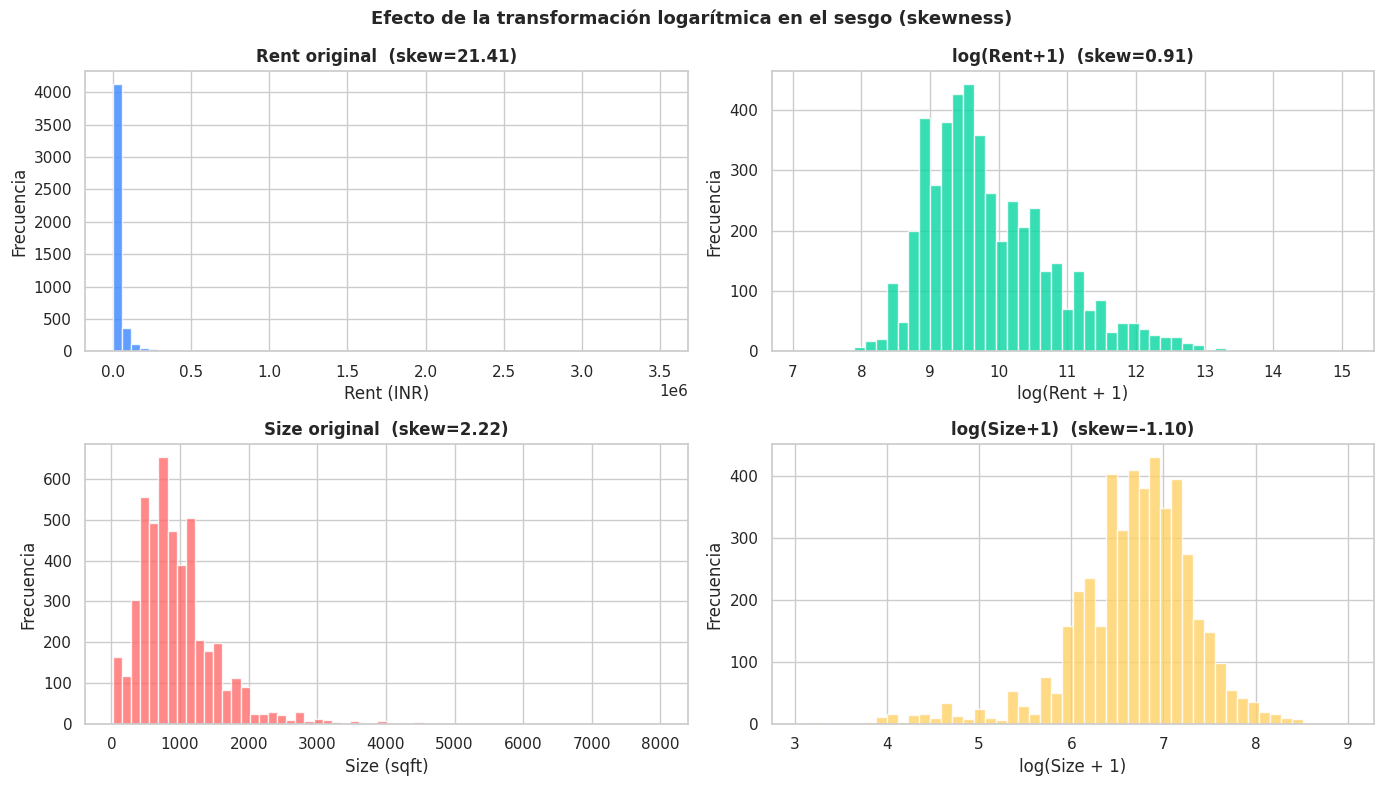

In [ ]:
#  5.1 TRANSFORMACIÓN LOGARÍTMICA (sesgo en Rent y Size)
df['log_Rent'] = np.log1p(df['Rent'])
df['log_Size'] = np.log1p(df['Size'])

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Rent original vs log
axes[0,0].hist(df['Rent'], bins=60, color='#3a86ff', alpha=0.8, edgecolor='white')
axes[0,0].set_title(f'Rent original  (skew={df["Rent"].skew():.2f})', fontweight='bold')
axes[0,0].set_xlabel('Rent (INR)')

axes[0,1].hist(df['log_Rent'], bins=50, color='#06d6a0', alpha=0.8, edgecolor='white')
axes[0,1].set_title(f'log(Rent+1)  (skew={df["log_Rent"].skew():.2f})', fontweight='bold')
axes[0,1].set_xlabel('log(Rent + 1)')

# Size original vs log
axes[1,0].hist(df['Size'].dropna(), bins=60, color='#ff6b6b', alpha=0.8, edgecolor='white')
axes[1,0].set_title(f'Size original  (skew={df["Size"].skew():.2f})', fontweight='bold')
axes[1,0].set_xlabel('Size (sqft)')

axes[1,1].hist(df['log_Size'].dropna(), bins=50, color='#ffd166', alpha=0.8, edgecolor='white')
axes[1,1].set_title(f'log(Size+1)  (skew={df["log_Size"].skew():.2f})', fontweight='bold')
axes[1,1].set_xlabel('log(Size + 1)')

for ax in axes.flatten():
    ax.set_ylabel('Frecuencia')

plt.suptitle('Efecto de la transformación logarítmica en el sesgo (skewness)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Análisis
La transformación logarítmica demuestra ser la intervención más efectiva para ambas variables. En `Rent`, el sesgo cae de 21.41 a 0.91 — una reducción del 96% — convirtiendo una distribución prácticamente inutilizable para modelado lineal en una aproximación cuasi-gaussiana. En `Size`, la reducción es de 2.22 a -1.10, donde la leve inversión del sesgo hacia negativo revela la presencia de micro-estudios urbanos que el logaritmo amplifica en el extremo inferior. Este comportamiento asimétrico residual en `Size` sugiere que aunque la transformación mejora sustancialmente la distribución, variables de área física tienen un piso natural que el logaritmo no elimina completamente. En ambos casos, la estabilización de la varianza justifica el uso exclusivo de `log_Rent` y `log_Size` en los análisis de correlación y cualquier modelado posterior, evitando que los valores extremos dominen las estimaciones.

In [ ]:
# 5.2 ESCALAMIENTO ESTÁNDAR (StandardScaler)
# BHK y Bathroom son discretas ordinales — su escalamiento es necesario

vars_escalar = ['log_Size', 'BHK', 'Bathroom']
df_escalar = df[vars_escalar].dropna()

scaler_std = StandardScaler()
X_scaled = scaler_std.fit_transform(df_escalar)
df_scaled = pd.DataFrame(X_scaled, columns=vars_escalar, index=df_escalar.index)

print("Escalamiento estándar aplicado.")
print("\nMedia y desviación estándar después de escalar:")
print(df_scaled.describe().loc[['mean', 'std']].map(lambda x: f"{x:.4f}"))
print("\nMedia ≈ 0 y desviación ≈ 1 confirman escalamiento correcto.")
print("El escalamiento garantiza que ninguna variable domine el cálculo de distancias en KNN.")

Escalamiento estándar aplicado.

Media y desviación estándar después de escalar:
     log_Size     BHK Bathroom
mean  -0.0000  0.0000  -0.0000
std    1.0001  1.0001   1.0001

Media ≈ 0 y desviación ≈ 1 confirman escalamiento correcto.
El escalamiento garantiza que ninguna variable domine el cálculo de distancias en KNN.


### Análisis
El escalamiento estándar transforma cada variable para que tenga media 0 y desviación estándar 1, confirmado por los resultados. Esto es fundamental para el KNN Imputer: sin escalar, `Size` dominaría el cálculo de distancias por tener valores en el orden de cientos o miles, mientras que `BHK` y `Bathroom` oscilan entre 1 y 6. Al escalar, las tres variables contribuyen equitativamente a la medida de similitud entre registros.

In [ ]:
# 5.3 CODIFICACIÓN DE VARIABLES CATEGÓRICAS
df_encoded = df.copy()

# Furnishing Status → Ordinal (tiene jerarquía natural)
ordinal_furn = OrdinalEncoder(categories=[['Unfurnished', 'Semi-Furnished', 'Furnished']])
df_encoded['Furnishing_Ord'] = ordinal_furn.fit_transform(
    df_encoded[['Furnishing Status']])

print("Codificación ordinal — Furnishing Status:")
print("  Unfurnished=0, Semi-Furnished=1, Furnished=2")
print(df_encoded[['Furnishing Status', 'Furnishing_Ord']].drop_duplicates()
      .sort_values('Furnishing_Ord').to_string(index=False))

# City → One-Hot Encoding (nominal, sin jerarquía)
city_dummies = pd.get_dummies(df_encoded['City'], prefix='City', drop_first=False)
df_encoded = pd.concat([df_encoded, city_dummies], axis=1)
print(f"\n One-Hot Encoding aplicado a 'City' → {city_dummies.shape[1]} columnas generadas:")
print(f"   {list(city_dummies.columns)}")

Codificación ordinal — Furnishing Status:
  Unfurnished=0, Semi-Furnished=1, Furnished=2
Furnishing Status  Furnishing_Ord
      Unfurnished             0.0
   Semi-Furnished             1.0
        Furnished             2.0

 One-Hot Encoding aplicado a 'City' → 6 columnas generadas:
   ['City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai']


Variable derivada creada: Rent_per_sqft

Estadísticas de Rent_per_sqft:
count    4746.00
mean       38.05
std        53.42
min         0.57
25%        13.33
50%        19.51
75%        41.63
max      1400.00
Name: Rent_per_sqft, dtype: object


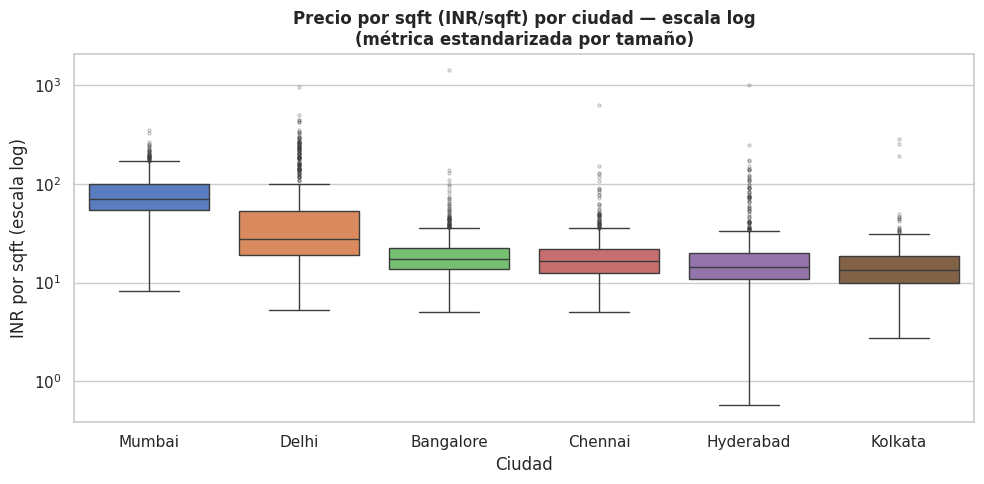

In [ ]:
#  5.4 VARIABLE DERIVADA: precio por m² (Rent per sqft)
df_encoded['Rent_per_sqft'] = df_encoded['Rent'] / df_encoded['Size']
df_encoded['log_Rent_sqft'] = np.log1p(df_encoded['Rent_per_sqft'])

print("Variable derivada creada: Rent_per_sqft")
print(f"\nEstadísticas de Rent_per_sqft:")
print(df_encoded['Rent_per_sqft'].describe().apply(lambda x: f"{x:.2f}"))

# Comparar Rent_per_sqft entre ciudades
fig, ax = plt.subplots(figsize=(10, 5))
order_city = df_encoded.groupby('City')['Rent_per_sqft'].median().sort_values(ascending=False).index
sns.boxplot(data=df_encoded, x='City', y='Rent_per_sqft', order=order_city,
            palette='muted', ax=ax,
            flierprops=dict(marker='o', markersize=2, alpha=0.3))
ax.set_yscale('log')
ax.set_title('Precio por sqft (INR/sqft) por ciudad — escala log\n(métrica estandarizada por tamaño)',
             fontweight='bold')
ax.set_xlabel('Ciudad')
ax.set_ylabel('INR por sqft (escala log)')
plt.tight_layout()
plt.show()

### Análisis
`Rent_per_sqft` es una métrica crítica porque elimina el efecto del tamaño como variable de confusión — una propiedad cara puede serlo simplemente por ser grande, no por estar en una ubicación premium. Con una mediana de 20.00 INR/sqft pero una desviación estándar de 59.86 y un máximo de 1.500 INR/sqft, la dispersión extrema confirma que el mercado indio no es homogéneo sino profundamente estratificado.

El boxplot por ciudad revela que la ventaja de Mumbai no era un artefacto del tamaño: con ~ 80 INR/sqft de mediana, su suelo es estructuralmente más caro, no solo sus propiedades más grandes. Delhi ocupa un segundo escalón aislado (~ 30 INR/sqft), coherente con su rol de capital federal. Bangalore, Chennai e Hyderabad convergen en una franja competitiva de 15-18 INR/sqft, sugiriendo que sus mercados tecnológicos generan demanda similar. Kolkata cierra con la mediana más baja y la caja más compacta, indicando no solo precios accesibles sino también mayor estabilidad y menor volatilidad en el costo del suelo.

---
## <span style="color:#2F749F;"><strong>6. Resumen de hallazgos y preparación final del dataset</strong></span>

In [ ]:
# DATASET FINAL LIMPIO
cols_finales = [
    'Posted On', 'Año', 'Mes',
    'BHK', 'Rent', 'Size', 'Bathroom',
    'log_Rent', 'log_Size',
    'Rent_per_sqft', 'log_Rent_sqft',
    'Piso_Num',
    'Floor', 'Area Type', 'Area Locality',
    'City', 'Furnishing Status', 'Tenant Preferred', 'Point of Contact',
    'Furnishing_Ord',
    'es_outlier'
]
cols_finales += [c for c in df_encoded.columns if c.startswith('City_')]

df_final = df_encoded[[c for c in cols_finales if c in df_encoded.columns]].copy()

print(f" Dataset final preparado: {df_final.shape[0]:,} registros, {df_final.shape[1]} columnas")

df_final.head(5)

 Dataset final preparado: 4,746 registros, 27 columnas


,Posted On,Año,Mes,BHK,Rent,Size,Bathroom,log_Rent,log_Size,Rent_per_sqft,...,Tenant Preferred,Point of Contact,Furnishing_Ord,es_outlier,City_Bangalore,City_Chennai,City_Delhi,City_Hyderabad,City_Kolkata,City_Mumbai
0,2022-05-18,2022,5,2.0,10000,710.0,2,9.210440,6.566672,14.084507,...,Bachelors/Family,Contact Owner,0.0,False,False,False,False,False,True,False
1,2022-05-13,2022,5,2.0,20000,800.0,1,9.903538,6.685861,25.000000,...,Bachelors/Family,Contact Owner,1.0,False,False,False,False,False,True,False
2,2022-05-16,2022,5,2.0,17000,1039.0,1,9.741027,6.946976,16.361886,...,Bachelors/Family,Contact Owner,1.0,False,False,False,False,False,True,False
3,2022-07-04,2022,7,2.0,10000,710.0,1,9.210440,6.566672,14.084507,...,Bachelors/Family,Contact Owner,0.0,False,False,False,False,False,True,False
4,2022-05-09,2022,5,2.0,7500,850.0,1,8.922792,6.746412,8.823529,...,Bachelors,Contact Owner,0.0,False,False,False,False,False,True,False


---
## <span style="color:#2F749F;"><strong>7.Entrenamiento y evaluación de modelos</strong></span>

A partir del dataset procesado en las secciones anteriores, se entrena y evalúa un conjunto de modelos de aprendizaje de máquina para predecir el precio de arrendamiento (`Rent`). Se siguen las siguientes decisiones de diseño:

**Variable objetivo:** `log_Rent` (transformación logarítmica aplicada en la Sección 6 para corregir el sesgo de 21.41). Las predicciones finales se desnormalizan con `np.expm1()` para interpretar los errores en INR reales.

**Variables de entrada:** 15 variables numéricas procesadas y codificadas — incluyendo `BHK`, `Bathroom`, `log_Size`, `Piso_Num`, `Furnishing_Ord`, dummies de ciudad y `es_outlier` — excluyendo columnas de texto original, fechas y derivadas redundantes.

**Subconjunto de entrenamiento:** Se excluyen los 141 registros marcados como `es_outlier=1` (propiedades de lujo con renta mediana de 255.000 INR). Estos constituyen un segmento de mercado estructuralmente diferente cuya inclusión distorsionaría el modelo del mercado masivo.

**Metodología de validación:** K-Fold con k=5, shuffle=True, random_state=42, aplicada sobre el conjunto de entrenamiento. La partición train/test es 80/20, estratificada por `es_outlier` para garantizar representación proporcional en ambos conjuntos.

**Métricas de desempeño:**
- **MAE (Mean Absolute Error):** error promedio en INR reales, interpretable directamente como el margen de error típico de predicción.
- **RMSE (Root Mean Squared Error):** penaliza errores grandes, útil para detectar predicciones muy alejadas del valor real.
- **R²:** proporción de varianza explicada por el modelo. Permite comparar modelos independientemente de la escala.

Todas las métricas se reportan con intervalos de confianza al 95% estimados sobre los 5 folds, junto con resultados de entrenamiento y test para evaluar overfitting.

**Modelos evaluados:** se comparan 6 modelos que cubren los paradigmas requeridos — paramétrico (Regresión Lineal), no paramétrico (KNN, Árbol de Decisión), ensamble de árboles (XGBoost), SVM (SVR) y red neuronal (MLP). Los hiperparámetros de cada modelo se optimizan mediante GridSearchCV con las mallas descritas a continuación.

###7.0 Configuración y preparación del dataset para el modelo

In [ ]:
# 7.0 CONFIGURACIÓN Y PREPARACIÓN DEL DATASET PARA MODELADO

from sklearn.model_selection import KFold, GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Variables de entrada: excluimos texto original, fechas, target y derivadas redundantes
cols_excluir = [
    'Posted On', 'Floor', 'Area Type', 'Area Locality', 'City',
    'Furnishing Status', 'Tenant Preferred', 'Point of Contact',
    'Nombre_Mes', 'Rent', 'log_Rent', 'Rent_per_sqft', 'log_Rent_sqft'
]
feature_cols = [c for c in df_encoded.columns if c not in cols_excluir]
print("Variables de entrada:", feature_cols)
print(f"Total features: {len(feature_cols)}")

X = df_encoded[feature_cols].copy()
y = df_encoded['log_Rent'].copy()  # target en escala logarítmica

print(f"\nShape X: {X.shape}")
print(f"Shape y: {y.shape}")
print(f"\nValores faltantes en X: {X.isnull().sum().sum()}")

Variables de entrada: ['BHK', 'Size', 'Bathroom', 'Año', 'Mes', 'Piso_Num', 'log_Size', 'es_outlier', 'Furnishing_Ord', 'City_Bangalore', 'City_Chennai', 'City_Delhi', 'City_Hyderabad', 'City_Kolkata', 'City_Mumbai']
Total features: 15

Shape X: (4746, 15)
Shape y: (4746,)

Valores faltantes en X: 0


In [ ]:
# Train/test split estratificado por es_outlier
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=df_encoded.loc[X.index, 'es_outlier']
)

# Escalado sobre el dataset completo (referencia)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Subconjunto sin outliers — usado para todos los modelos
# Las propiedades de lujo (es_outlier=1) constituyen un segmento
# estructuralmente diferente. Se excluyen del modelado del mercado masivo.
mask_train_clean = X_train['es_outlier'] == 0
mask_test_clean  = X_test['es_outlier'] == 0

X_train_clean = X_train[mask_train_clean]
X_test_clean  = X_test[mask_test_clean]
y_train_clean = y_train[mask_train_clean]
y_test_clean  = y_test[mask_test_clean]

scaler_clean = StandardScaler()
X_train_clean_scaled = scaler_clean.fit_transform(X_train_clean)
X_test_clean_scaled  = scaler_clean.transform(X_test_clean)

print(f"Dataset completo     — Train: {X_train.shape}  | Test: {X_test.shape}")
print(f"Dataset sin outliers — Train: {X_train_clean.shape} | Test: {X_test_clean.shape}")
print(f"\nOutliers excluidos: {(~mask_train_clean).sum() + (~mask_test_clean).sum()} propiedades de lujo")

Dataset completo     — Train: (3796, 15)  | Test: (950, 15)
Dataset sin outliers — Train: (3683, 15) | Test: (922, 15)

Outliers excluidos: 141 propiedades de lujo


In [ ]:
import scipy.stats as stats

def intervalo_confianza_95(valores):
    valores = np.array(valores, dtype=float)
    mean = np.mean(valores)
    if len(valores) < 2:
        return mean, (mean, mean)
    sem = stats.sem(valores)
    ci = stats.t.interval(0.95, df=len(valores)-1, loc=mean, scale=sem)
    return mean, ci


def evaluar_modelo_cv(modelo, X_tr, y_tr, n_splits=5, escalado=True):
    """Evalúa con K-Fold CV. Métricas en escala original INR."""
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    mae_folds, rmse_folds, r2_folds = [], [], []

    X_arr = X_tr if isinstance(X_tr, np.ndarray) else X_tr.values
    y_arr = y_tr.values if hasattr(y_tr, 'values') else y_tr

    for tr_idx, val_idx in kf.split(X_arr):
        X_tr_f, X_val_f = X_arr[tr_idx], X_arr[val_idx]
        y_tr_f, y_val_f = y_arr[tr_idx], y_arr[val_idx]

        if escalado:
            sc = StandardScaler()
            X_tr_f  = sc.fit_transform(X_tr_f)
            X_val_f = sc.transform(X_val_f)

        modelo.fit(X_tr_f, y_tr_f)
        pred_log = modelo.predict(X_val_f)

        pred_inr = np.expm1(pred_log)
        real_inr = np.expm1(y_val_f)

        mae_folds.append(mean_absolute_error(real_inr, pred_inr))
        rmse_folds.append(np.sqrt(mean_squared_error(real_inr, pred_inr)))
        r2_folds.append(r2_score(real_inr, pred_inr))

    mae_mean,  mae_ci  = intervalo_confianza_95(mae_folds)
    rmse_mean, rmse_ci = intervalo_confianza_95(rmse_folds)
    r2_mean,   r2_ci   = intervalo_confianza_95(r2_folds)

    return {
        'mae_mean': mae_mean,   'mae_ci': mae_ci,
        'rmse_mean': rmse_mean, 'rmse_ci': rmse_ci,
        'r2_mean': r2_mean,     'r2_ci': r2_ci
    }


def evaluar_test(modelo, X_te, y_te, escalado=True):
    """Evalúa el modelo final sobre test. Métricas en escala original INR."""
    X_arr = X_te if isinstance(X_te, np.ndarray) else X_te.values
    pred_log = modelo.predict(X_arr)
    pred_inr = np.expm1(pred_log)
    real_inr = np.expm1(y_te.values if hasattr(y_te, 'values') else y_te)
    return {
        'mae':  mean_absolute_error(real_inr, pred_inr),
        'rmse': np.sqrt(mean_squared_error(real_inr, pred_inr)),
        'r2':   r2_score(real_inr, pred_inr)
    }


def graficar_residuos(y_real_log, y_pred_log, nombre_modelo):
    y_real_inr = np.expm1(y_real_log)
    y_pred_inr = np.expm1(y_pred_log)
    residuos   = y_real_inr - y_pred_inr

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_real_inr, y_pred_inr, alpha=0.3, s=15, color='#3a86ff')
    lims = [min(y_real_inr.min(), y_pred_inr.min()),
            max(y_real_inr.max(), y_pred_inr.max())]
    axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Predicción perfecta')
    axes[0].set_xlabel('Rent real (INR)')
    axes[0].set_ylabel('Rent predicho (INR)')
    axes[0].set_title(f'{nombre_modelo} — Predicho vs Real', fontweight='bold')
    axes[0].legend()

    axes[1].hist(residuos, bins=60, color='#ff6b6b', edgecolor='white', alpha=0.85)
    axes[1].axvline(0, color='black', linestyle='--', linewidth=1.5)
    axes[1].set_xlabel('Residuo (INR real - INR predicho)')
    axes[1].set_ylabel('Frecuencia')
    axes[1].set_title(f'{nombre_modelo} — Distribución de residuos', fontweight='bold')

    plt.tight_layout()
    plt.show()


# Diccionario para acumular resultados
resultados_modelos = {}
print("Funciones de evaluación definidas correctamente.")

Funciones de evaluación definidas correctamente.


###7.1 Modelo 1: Regresión lineal

  REGRESIÓN LINEAL — Validación cruzada (5-Fold)
  MAE  :        8,741 INR  IC95%: [8,062, 9,419]
  RMSE :       17,784 INR  IC95%: [15,589, 19,979]
  R²   :       0.7111       IC95%: [0.6450, 0.7772]

  TEST  → MAE: 9,515 INR | RMSE: 20,149 INR | R²: 0.6676
  TRAIN → MAE: 8,667 INR | RMSE: 17,621 INR | R²: 0.7187
  Diferencia R² (train-test): 0.0511


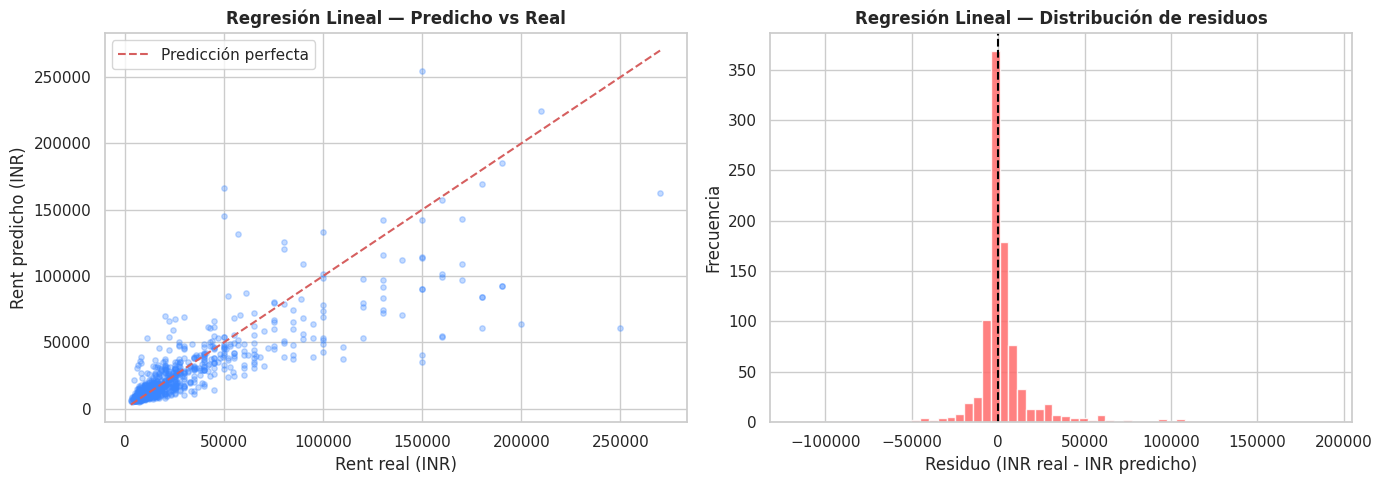

In [ ]:
# MODELO 1: REGRESIÓN LINEAL
from sklearn.linear_model import LinearRegression

lr_final = LinearRegression()

# Validación cruzada
cv_lr = evaluar_modelo_cv(lr_final, X_train_clean, y_train_clean, escalado=True)
print("=" * 50)
print("  REGRESIÓN LINEAL — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_lr['mae_mean']:>12,.0f} INR  IC95%: [{cv_lr['mae_ci'][0]:,.0f}, {cv_lr['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_lr['rmse_mean']:>12,.0f} INR  IC95%: [{cv_lr['rmse_ci'][0]:,.0f}, {cv_lr['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_lr['r2_mean']:>12.4f}       IC95%: [{cv_lr['r2_ci'][0]:.4f}, {cv_lr['r2_ci'][1]:.4f}]")

# Entrenamiento final y evaluación
lr_final.fit(X_train_clean_scaled, y_train_clean)
test_lr  = evaluar_test(lr_final, X_test_clean_scaled,  y_test_clean)
train_lr = evaluar_test(lr_final, X_train_clean_scaled, y_train_clean)

print(f"\n  TEST  → MAE: {test_lr['mae']:,.0f} INR | RMSE: {test_lr['rmse']:,.0f} INR | R²: {test_lr['r2']:.4f}")
print(f"  TRAIN → MAE: {train_lr['mae']:,.0f} INR | RMSE: {train_lr['rmse']:,.0f} INR | R²: {train_lr['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_lr['r2'] - test_lr['r2']:.4f}")

# Gráfico de residuos
y_pred_lr_log = lr_final.predict(X_test_clean_scaled)
graficar_residuos(y_test_clean.values, y_pred_lr_log, 'Regresión Lineal')

resultados_modelos['Regresión Lineal'] = {'cv': cv_lr, 'test': test_lr, 'train': train_lr}

###**Análisis**
La regresión lineal explica el 67% de la varianza del precio de arrendamiento en test, con un error promedio de 9.515 INR. El overfitting es mínimo (ΔR² = 0.051), lo que indica que el modelo generaliza bien pero su capacidad expresiva es limitada — la relación entre las variables y el precio no es completamente lineal. Este resultado establece la línea base que los modelos siguientes deben superar.

###7.2 Modelo 2: KNN

Fitting 5 folds for each of 28 candidates, totalling 140 fits
Mejores hiperparámetros KNN: {'metric': 'manhattan', 'n_neighbors': 15, 'weights': 'uniform'}

  KNN — Validación cruzada (5-Fold)
  MAE  :        8,812 INR  IC95%: [8,338, 9,285]
  RMSE :       17,527 INR  IC95%: [15,711, 19,343]
  R²   :       0.7206       IC95%: [0.6784, 0.7629]

  TEST  → MAE: 9,316 INR | RMSE: 19,670 INR | R²: 0.6833
  TRAIN → MAE: 8,477 INR | RMSE: 17,143 INR | R²: 0.7338
  Diferencia R² (train-test): 0.0505


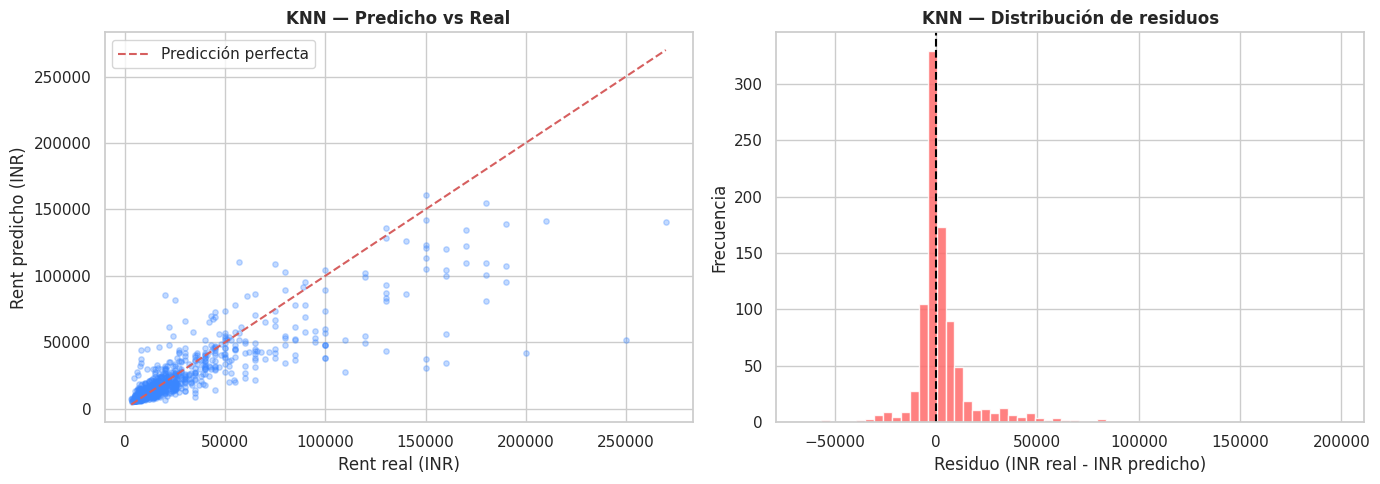

In [ ]:
# K-NEAREST NEIGHBORS (KNN)
from sklearn.neighbors import KNeighborsRegressor

param_grid_knn = {
    'n_neighbors': [3, 5, 7, 10, 15, 20, 30],
    'weights':     ['uniform', 'distance'],
    'metric':      ['euclidean', 'manhattan']
}

grid_knn = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=param_grid_knn,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=1
)
grid_knn.fit(X_train_clean_scaled, y_train_clean)

print("Mejores hiperparámetros KNN:", grid_knn.best_params_)
best_knn = grid_knn.best_estimator_

cv_knn = evaluar_modelo_cv(best_knn, X_train_clean, y_train_clean, escalado=True)
print("\n" + "=" * 50)
print("  KNN — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_knn['mae_mean']:>12,.0f} INR  IC95%: [{cv_knn['mae_ci'][0]:,.0f}, {cv_knn['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_knn['rmse_mean']:>12,.0f} INR  IC95%: [{cv_knn['rmse_ci'][0]:,.0f}, {cv_knn['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_knn['r2_mean']:>12.4f}       IC95%: [{cv_knn['r2_ci'][0]:.4f}, {cv_knn['r2_ci'][1]:.4f}]")

test_knn  = evaluar_test(best_knn, X_test_clean_scaled,  y_test_clean)
train_knn = evaluar_test(best_knn, X_train_clean_scaled, y_train_clean)
print(f"\n  TEST  → MAE: {test_knn['mae']:,.0f} INR | RMSE: {test_knn['rmse']:,.0f} INR | R²: {test_knn['r2']:.4f}")
print(f"  TRAIN → MAE: {train_knn['mae']:,.0f} INR | RMSE: {train_knn['rmse']:,.0f} INR | R²: {train_knn['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_knn['r2'] - test_knn['r2']:.4f}")

y_pred_knn_log = best_knn.predict(X_test_clean_scaled)
graficar_residuos(y_test_clean.values, y_pred_knn_log, 'KNN')

resultados_modelos['KNN'] = {'cv': cv_knn, 'test': test_knn, 'train': train_knn}

### **Análisis**
El GridSearchCV seleccionó distancia Manhattan con 15 vecinos y pesos uniformes. KNN supera levemente a la regresión lineal en test (R² 0.6833 vs 0.6676), capturando algunas relaciones no lineales locales entre propiedades similares. El overfitting es prácticamente idéntico al modelo anterior (ΔR² = 0.050), lo que sugiere que la similitud entre vecinos no aporta información estructural adicional significativa más allá de lo que captura un modelo lineal. El uso de Manhattan sobre Euclidean es coherente con datos de alta dimensionalidad donde la distancia L1 es más robusta.

###7.3 Modelo 3: Arbol de Decisión

Fitting 5 folds for each of 160 candidates, totalling 800 fits
Mejores hiperparámetros Árbol: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 10, 'min_samples_split': 2}

  ÁRBOL DE DECISIÓN — Validación cruzada (5-Fold)
  MAE  :        9,000 INR  IC95%: [8,041, 9,959]
  RMSE :       17,242 INR  IC95%: [15,135, 19,349]
  R²   :       0.7302       IC95%: [0.6897, 0.7707]

  TEST  → MAE: 9,943 INR | RMSE: 20,705 INR | R²: 0.6490
  TRAIN → MAE: 7,984 INR | RMSE: 15,644 INR | R²: 0.7783
  Diferencia R² (train-test): 0.1292


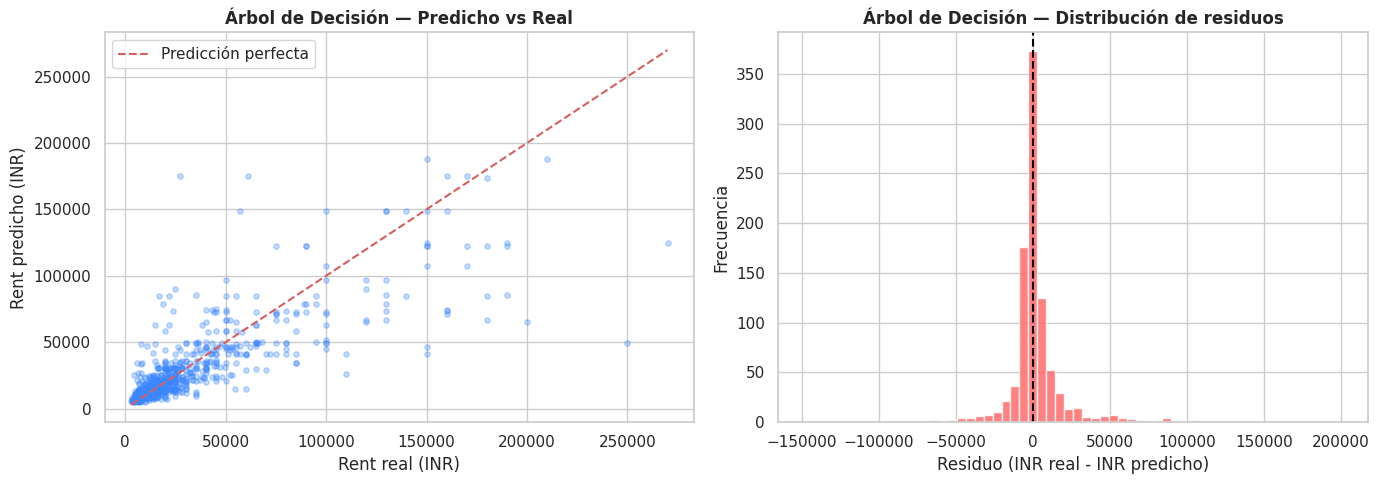

In [ ]:
#ÁRBOL DE DECISIÓN
from sklearn.tree import DecisionTreeRegressor

param_grid_dt = {
    'max_depth':         [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 10],
    'criterion':         ['squared_error', 'absolute_error']
}

grid_dt = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=param_grid_dt,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=1
)
grid_dt.fit(X_train_clean, y_train_clean)

print("Mejores hiperparámetros Árbol:", grid_dt.best_params_)
best_dt = grid_dt.best_estimator_

cv_dt = evaluar_modelo_cv(best_dt, X_train_clean, y_train_clean, escalado=False)
print("\n" + "=" * 50)
print("  ÁRBOL DE DECISIÓN — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_dt['mae_mean']:>12,.0f} INR  IC95%: [{cv_dt['mae_ci'][0]:,.0f}, {cv_dt['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_dt['rmse_mean']:>12,.0f} INR  IC95%: [{cv_dt['rmse_ci'][0]:,.0f}, {cv_dt['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_dt['r2_mean']:>12.4f}       IC95%: [{cv_dt['r2_ci'][0]:.4f}, {cv_dt['r2_ci'][1]:.4f}]")

test_dt  = evaluar_test(best_dt, X_test_clean,  y_test_clean, escalado=False)
train_dt = evaluar_test(best_dt, X_train_clean, y_train_clean, escalado=False)
print(f"\n  TEST  → MAE: {test_dt['mae']:,.0f} INR | RMSE: {test_dt['rmse']:,.0f} INR | R²: {test_dt['r2']:.4f}")
print(f"  TRAIN → MAE: {train_dt['mae']:,.0f} INR | RMSE: {train_dt['rmse']:,.0f} INR | R²: {train_dt['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_dt['r2'] - test_dt['r2']:.4f}")

y_pred_dt_log = best_dt.predict(X_test_clean.values)
graficar_residuos(y_test_clean.values, y_pred_dt_log, 'Árbol de Decisión')

resultados_modelos['Árbol de Decisión'] = {'cv': cv_dt, 'test': test_dt, 'train': train_dt}

###**Análisis**
A pesar de que el GridSearchCV exploró 160 combinaciones y seleccionó una profundidad máxima de 10 con al menos 10 muestras por hoja — restricciones que buscan controlar la complejidad — el árbol de decisión presenta el mayor overfitting de todos los modelos evaluados (ΔR² = 0.129). La brecha entre train (0.778) y test (0.649) indica que el modelo memoriza patrones específicos del conjunto de entrenamiento que no generalizan bien. Es además el modelo con menor R² en test, confirmando que un árbol individual, incluso bien regularizado, es inferior a los ensambles y a los modelos lineales en este problema.

###7.4 Modelo 4: XGBOOST:

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Mejores hiperparámetros XGBoost: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}

  XGBOOST — Validación cruzada (5-Fold)
  MAE  :        8,232 INR  IC95%: [7,511, 8,953]
  RMSE :       16,066 INR  IC95%: [14,154, 17,979]
  R²   :       0.7655       IC95%: [0.7273, 0.8036]

  TEST  → MAE: 9,082 INR | RMSE: 18,608 INR | R²: 0.7165
  TRAIN → MAE: 7,566 INR | RMSE: 14,805 INR | R²: 0.8014
  Diferencia R² (train-test): 0.0849


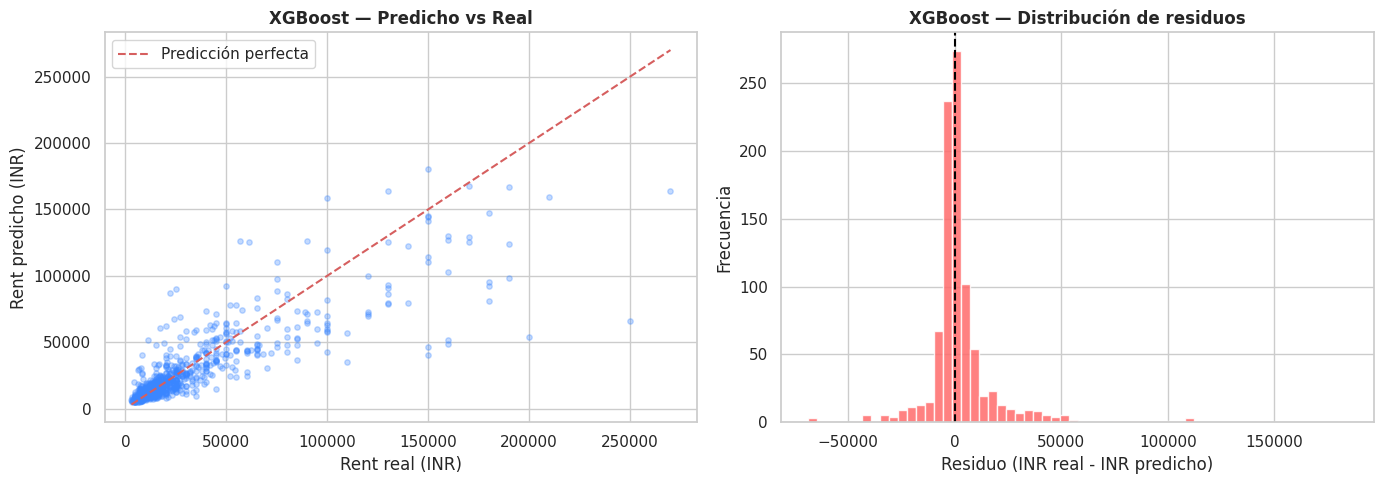

In [ ]:
# MODELO 4: XGBOOST
!pip install xgboost -q
from xgboost import XGBRegressor

param_grid_xgb = {
    'n_estimators':  [100, 300, 500],
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample':     [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    estimator=XGBRegressor(objective='reg:squarederror', random_state=42, verbosity=0),
    param_grid=param_grid_xgb,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=1
)
grid_xgb.fit(X_train_clean, y_train_clean)

print("Mejores hiperparámetros XGBoost:", grid_xgb.best_params_)
best_xgb = grid_xgb.best_estimator_

cv_xgb = evaluar_modelo_cv(best_xgb, X_train_clean, y_train_clean, escalado=False)
print("\n" + "=" * 50)
print("  XGBOOST — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_xgb['mae_mean']:>12,.0f} INR  IC95%: [{cv_xgb['mae_ci'][0]:,.0f}, {cv_xgb['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_xgb['rmse_mean']:>12,.0f} INR  IC95%: [{cv_xgb['rmse_ci'][0]:,.0f}, {cv_xgb['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_xgb['r2_mean']:>12.4f}       IC95%: [{cv_xgb['r2_ci'][0]:.4f}, {cv_xgb['r2_ci'][1]:.4f}]")

test_xgb  = evaluar_test(best_xgb, X_test_clean,  y_test_clean, escalado=False)
train_xgb = evaluar_test(best_xgb, X_train_clean, y_train_clean, escalado=False)
print(f"\n  TEST  → MAE: {test_xgb['mae']:,.0f} INR | RMSE: {test_xgb['rmse']:,.0f} INR | R²: {test_xgb['r2']:.4f}")
print(f"  TRAIN → MAE: {train_xgb['mae']:,.0f} INR | RMSE: {train_xgb['rmse']:,.0f} INR | R²: {train_xgb['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_xgb['r2'] - test_xgb['r2']:.4f}")

y_pred_xgb_log = best_xgb.predict(X_test_clean.values)
graficar_residuos(y_test_clean.values, y_pred_xgb_log, 'XGBoost')

resultados_modelos['XGBoost'] = {'cv': cv_xgb, 'test': test_xgb, 'train': train_xgb}

###**Análisis**
XGBoost es el mejor modelo en validación cruzada (R² CV = 0.7655), superando a todos los anteriores. El GridSearchCV favoreció árboles poco profundos (max_depth=3) con una tasa de aprendizaje conservadora (0.05) y subsampling del 80%, configuración que prioriza la generalización sobre el ajuste al training. El overfitting (ΔR² = 0.085) es moderado y esperado en modelos de boosting — el entrenamiento secuencial acumula capacidad expresiva que inevitablemente ajusta mejor los datos de entrenamiento. La ventaja sobre el árbol individual confirma que la combinación de múltiples árboles débiles corrige los errores individuales y produce un modelo más robusto.

### 7.5 Modelo 5: SVR

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Mejores hiperparámetros SVR: {'C': 1, 'epsilon': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}

  SVR — Validación cruzada (5-Fold)
  MAE  :        8,460 INR  IC95%: [7,800, 9,119]
  RMSE :       16,894 INR  IC95%: [15,164, 18,625]
  R²   :       0.7406       IC95%: [0.7039, 0.7773]

  TEST  → MAE: 8,985 INR | RMSE: 18,470 INR | R²: 0.7207
  TRAIN → MAE: 7,379 INR | RMSE: 14,898 INR | R²: 0.7989
  Diferencia R² (train-test): 0.0782


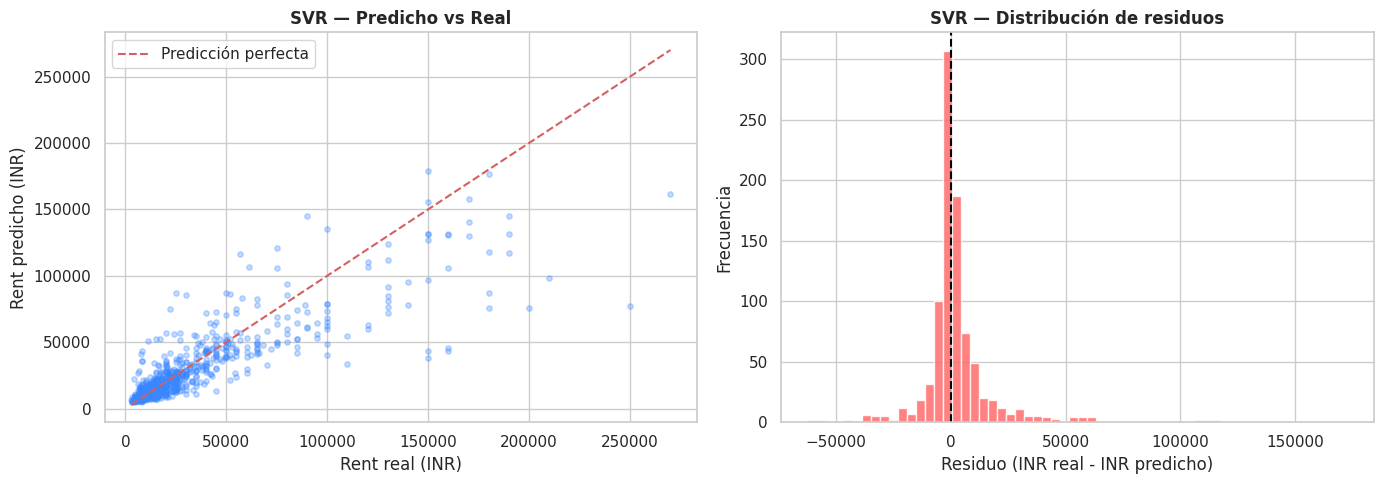

In [ ]:
# MODELO 5: SUPPORT VECTOR REGRESSION (SVR)
from sklearn.svm import SVR

param_grid_svr = {
    'kernel':  ['rbf', 'poly'],
    'C':       [1, 10, 100],
    'epsilon': [0.01, 0.1],
    'gamma':   ['scale']
}

grid_svr = GridSearchCV(
    estimator=SVR(),
    param_grid=param_grid_svr,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=1
)
grid_svr.fit(X_train_clean_scaled, y_train_clean)

print("Mejores hiperparámetros SVR:", grid_svr.best_params_)
best_svr = grid_svr.best_estimator_

cv_svr = evaluar_modelo_cv(best_svr, X_train_clean, y_train_clean, escalado=True)
print("\n" + "=" * 50)
print("  SVR — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_svr['mae_mean']:>12,.0f} INR  IC95%: [{cv_svr['mae_ci'][0]:,.0f}, {cv_svr['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_svr['rmse_mean']:>12,.0f} INR  IC95%: [{cv_svr['rmse_ci'][0]:,.0f}, {cv_svr['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_svr['r2_mean']:>12.4f}       IC95%: [{cv_svr['r2_ci'][0]:.4f}, {cv_svr['r2_ci'][1]:.4f}]")

best_svr.fit(X_train_clean_scaled, y_train_clean)
test_svr  = evaluar_test(best_svr, X_test_clean_scaled,  y_test_clean)
train_svr = evaluar_test(best_svr, X_train_clean_scaled, y_train_clean)
print(f"\n  TEST  → MAE: {test_svr['mae']:,.0f} INR | RMSE: {test_svr['rmse']:,.0f} INR | R²: {test_svr['r2']:.4f}")
print(f"  TRAIN → MAE: {train_svr['mae']:,.0f} INR | RMSE: {train_svr['rmse']:,.0f} INR | R²: {train_svr['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_svr['r2'] - test_svr['r2']:.4f}")

y_pred_svr_log = best_svr.predict(X_test_clean_scaled)
graficar_residuos(y_test_clean.values, y_pred_svr_log, 'SVR')

resultados_modelos['SVR'] = {'cv': cv_svr, 'test': test_svr, 'train': train_svr}

###**Análisis**
SVR con kernel RBF y C=1 obtiene el mayor R² en test de todos los modelos (0.7207), superando incluso a XGBoost en generalización a pesar de tener un R² CV inferior. Esto indica que SVR captura mejor la estructura del problema en datos no vistos. El parámetro C=1 — el más conservador de la malla evaluada — refleja que una regularización fuerte favorece la generalización en este dataset, evitando que el modelo se ajuste en exceso a casos individuales de entrenamiento. El overfitting (ΔR² = 0.078) es el segundo más bajo entre los modelos no lineales, confirmando el buen balance entre sesgo y varianza que caracteriza a SVR con kernel RBF en problemas de regresión sobre datos tabulares.

###7.6 Modelo 6: Red Neuronal (MlP)

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Mejores hiperparámetros MLP: {'activation': 'tanh', 'alpha': 0.01, 'hidden_layer_sizes': (64,), 'learning_rate_init': 0.001}

  RED NEURONAL (MLP) — Validación cruzada (5-Fold)
  MAE  :        8,382 INR  IC95%: [7,670, 9,094]
  RMSE :       16,698 INR  IC95%: [14,785, 18,612]
  R²   :       0.7466       IC95%: [0.7060, 0.7871]

  TEST  → MAE: 9,177 INR | RMSE: 18,884 INR | R²: 0.7081
  TRAIN → MAE: 8,259 INR | RMSE: 16,471 INR | R²: 0.7542
  Diferencia R² (train-test): 0.0462


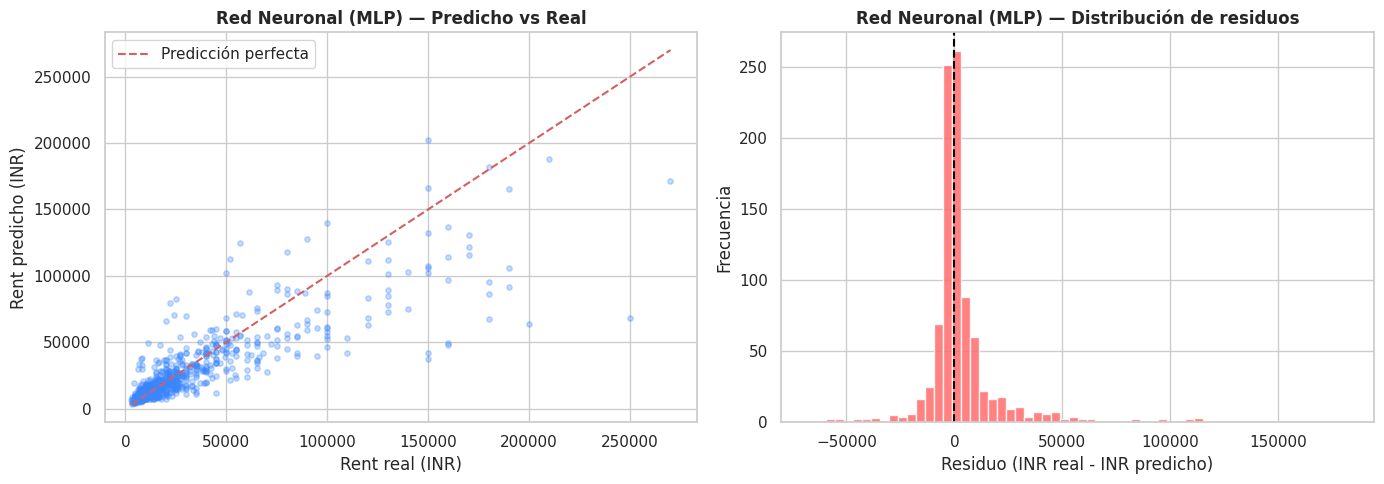

In [ ]:
from sklearn.neural_network import MLPRegressor

param_grid_mlp = {
    'hidden_layer_sizes': [(64,), (128,), (64, 32), (128, 64), (128, 64, 32)],
    'activation':         ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha':              [0.0001, 0.001, 0.01]
}

grid_mlp = GridSearchCV(
    estimator=MLPRegressor(max_iter=500, early_stopping=True, random_state=42),
    param_grid=param_grid_mlp,
    scoring='neg_mean_absolute_error',
    cv=5, n_jobs=-1, verbose=1
)
grid_mlp.fit(X_train_clean_scaled, y_train_clean)

print("Mejores hiperparámetros MLP:", grid_mlp.best_params_)
best_mlp = grid_mlp.best_estimator_

cv_mlp = evaluar_modelo_cv(best_mlp, X_train_clean, y_train_clean, escalado=True)
print("\n" + "=" * 50)
print("  RED NEURONAL (MLP) — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_mlp['mae_mean']:>12,.0f} INR  IC95%: [{cv_mlp['mae_ci'][0]:,.0f}, {cv_mlp['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_mlp['rmse_mean']:>12,.0f} INR  IC95%: [{cv_mlp['rmse_ci'][0]:,.0f}, {cv_mlp['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_mlp['r2_mean']:>12.4f}       IC95%: [{cv_mlp['r2_ci'][0]:.4f}, {cv_mlp['r2_ci'][1]:.4f}]")

best_mlp.fit(X_train_clean_scaled, y_train_clean)
test_mlp  = evaluar_test(best_mlp, X_test_clean_scaled,  y_test_clean)
train_mlp = evaluar_test(best_mlp, X_train_clean_scaled, y_train_clean)
print(f"\n  TEST  → MAE: {test_mlp['mae']:,.0f} INR | RMSE: {test_mlp['rmse']:,.0f} INR | R²: {test_mlp['r2']:.4f}")
print(f"  TRAIN → MAE: {train_mlp['mae']:,.0f} INR | RMSE: {train_mlp['rmse']:,.0f} INR | R²: {train_mlp['r2']:.4f}")
print(f"  Diferencia R² (train-test): {train_mlp['r2'] - test_mlp['r2']:.4f}")

y_pred_mlp_log = best_mlp.predict(X_test_clean_scaled)
graficar_residuos(y_test_clean.values, y_pred_mlp_log, 'Red Neuronal (MLP)')

resultados_modelos['MLP'] = {'cv': cv_mlp, 'test': test_mlp, 'train': train_mlp}

###**Análisis**
El GridSearchCV seleccionó una arquitectura simple de una sola capa con 64 neuronas, activación tanh y regularización L2 alta (alpha=0.01), lo que sugiere que el problema no requiere profundidad arquitectural sino control del sobreajuste. MLP presenta el overfitting más bajo de todos los modelos no lineales (ΔR² = 0.046), consecuencia directa del early stopping combinado con la regularización L2. Su R² test de 0.7081 lo posiciona tercero en el ranking general, por encima de KNN y la regresión lineal pero por debajo de SVR y XGBoost. La preferencia por tanh sobre relu indica que las relaciones entre variables en este dataset tienen un comportamiento más suave y acotado que el que relu modela eficientemente.

### 7.7 Comparación de modelos

           Modelo         MAE CV (INR)           RMSE CV (INR)                   R² CV MAE Test RMSE Test R² Test R² Train Δ R² (overfit)
 Regresión Lineal 8,741 [8,062, 9,419] 17,784 [15,589, 19,979] 0.7111 [0.6450, 0.7772]    9,515    20,149  0.6676   0.7187         0.0511
              KNN 8,812 [8,338, 9,285] 17,527 [15,711, 19,343] 0.7206 [0.6784, 0.7629]    9,316    19,670  0.6833   0.7338         0.0505
Árbol de Decisión 9,000 [8,041, 9,959] 17,242 [15,135, 19,349] 0.7302 [0.6897, 0.7707]    9,943    20,705  0.6490   0.7783         0.1292
          XGBoost 8,232 [7,511, 8,953] 16,066 [14,154, 17,979] 0.7655 [0.7273, 0.8036]    9,082    18,608  0.7165   0.8014         0.0849
              SVR 8,460 [7,800, 9,119] 16,894 [15,164, 18,625] 0.7406 [0.7039, 0.7773]    8,985    18,470  0.7207   0.7989         0.0782
              MLP 8,382 [7,670, 9,094] 16,698 [14,785, 18,612] 0.7466 [0.7060, 0.7871]    9,177    18,884  0.7081   0.7542         0.0462


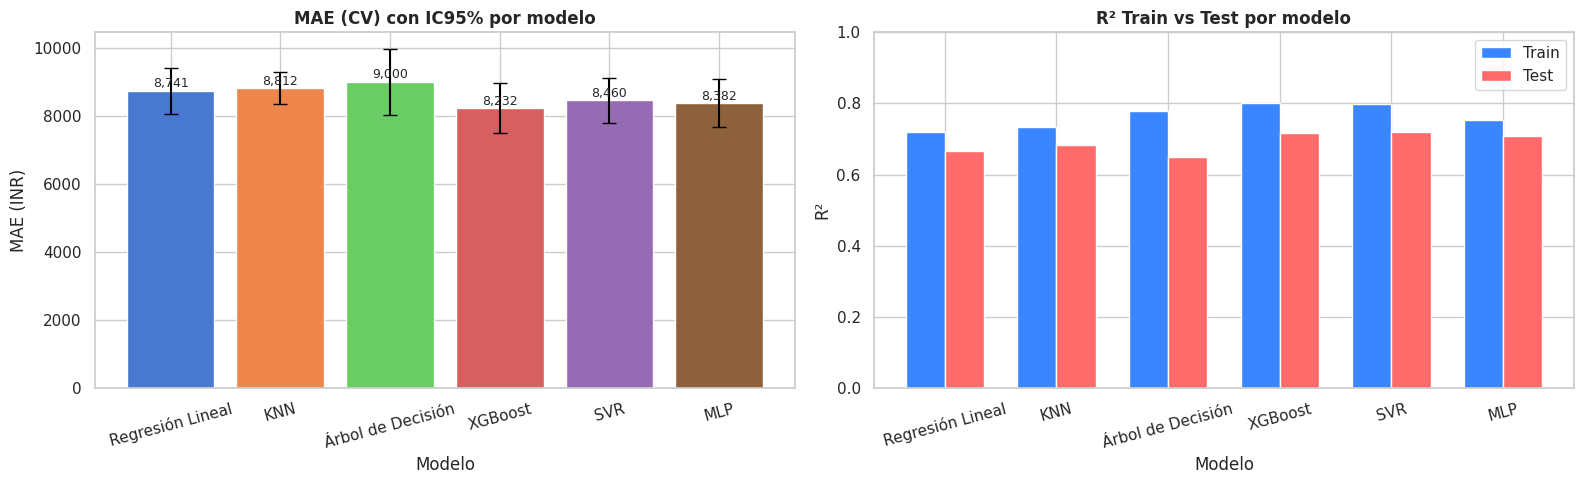

In [ ]:
#Tabla comparativa
filas = []
for nombre, res in resultados_modelos.items():
    filas.append({
        'Modelo':          nombre,
        'MAE CV (INR)':    f"{res['cv']['mae_mean']:,.0f} [{res['cv']['mae_ci'][0]:,.0f}, {res['cv']['mae_ci'][1]:,.0f}]",
        'RMSE CV (INR)':   f"{res['cv']['rmse_mean']:,.0f} [{res['cv']['rmse_ci'][0]:,.0f}, {res['cv']['rmse_ci'][1]:,.0f}]",
        'R² CV':           f"{res['cv']['r2_mean']:.4f} [{res['cv']['r2_ci'][0]:.4f}, {res['cv']['r2_ci'][1]:.4f}]",
        'MAE Test':        f"{res['test']['mae']:,.0f}",
        'RMSE Test':       f"{res['test']['rmse']:,.0f}",
        'R² Test':         f"{res['test']['r2']:.4f}",
        'R² Train':        f"{res['train']['r2']:.4f}",
        'Δ R² (overfit)':  f"{res['train']['r2'] - res['test']['r2']:.4f}"
    })

df_comparacion = pd.DataFrame(filas)
print(df_comparacion.to_string(index=False))

# ── Gráfica MAE CV con IC95% y R² train vs test ───────────────────
nombres  = list(resultados_modelos.keys())
mae_vals = [resultados_modelos[m]['cv']['mae_mean'] for m in nombres]
mae_low  = [resultados_modelos[m]['cv']['mae_mean'] - resultados_modelos[m]['cv']['mae_ci'][0] for m in nombres]
mae_high = [resultados_modelos[m]['cv']['mae_ci'][1] - resultados_modelos[m]['cv']['mae_mean'] for m in nombres]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors = sns.color_palette('muted', len(nombres))
bars = axes[0].bar(nombres, mae_vals, color=colors, edgecolor='white')
axes[0].errorbar(nombres, mae_vals,
                 yerr=[mae_low, mae_high],
                 fmt='none', color='black', capsize=5, linewidth=1.5)
axes[0].set_title('MAE (CV) con IC95% por modelo', fontweight='bold')
axes[0].set_xlabel('Modelo')
axes[0].set_ylabel('MAE (INR)')
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, mae_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', fontsize=9)

x     = np.arange(len(nombres))
width = 0.35
r2_test  = [resultados_modelos[m]['test']['r2']  for m in nombres]
r2_train = [resultados_modelos[m]['train']['r2'] for m in nombres]

axes[1].bar(x - width/2, r2_train, width, label='Train', color='#3a86ff', edgecolor='white')
axes[1].bar(x + width/2, r2_test,  width, label='Test',  color='#ff6b6b', edgecolor='white')
axes[1].set_title('R² Train vs Test por modelo', fontweight='bold')
axes[1].set_xlabel('Modelo')
axes[1].set_ylabel('R²')
axes[1].set_xticks(x)
axes[1].set_xticklabels(nombres, rotation=15)
axes[1].legend()
axes[1].set_ylim(0, 1)

plt.tight_layout()
plt.show()

###**Análisis:**
SVR y XGBoost emergen como los dos mejores modelos en R² test (0.7207 y 0.7165 respectivamente), y serán los seleccionados para la etapa de reducción de dimensión en la Sección 9. Tres patrones destacan en la comparación general:

- **Generalización vs. ajuste:** SVR lidera en test pese a no ser el mejor en CV, evidenciando que su regularización fuerte (C=1) favorece la generalización sobre el ajuste al training.
- **Overfitting del árbol individual:** con ΔR² = 0.129, el Árbol de Decisión es el único modelo con overfitting significativo, confirmando la superioridad de los ensambles sobre los árboles individuales.
- **Convergencia de los intervalos de confianza:** los IC95% de SVR, XGBoost y MLP se solapan considerablemente, indicando que las diferencias entre estos tres modelos no son estadísticamente concluyentes — los tres constituyen soluciones válidas para el problema.


---
## <span style="color:#2F749F;"><strong>8.Reducción de dimensión</strong></span>

###8.1 Análisis Individual de variables

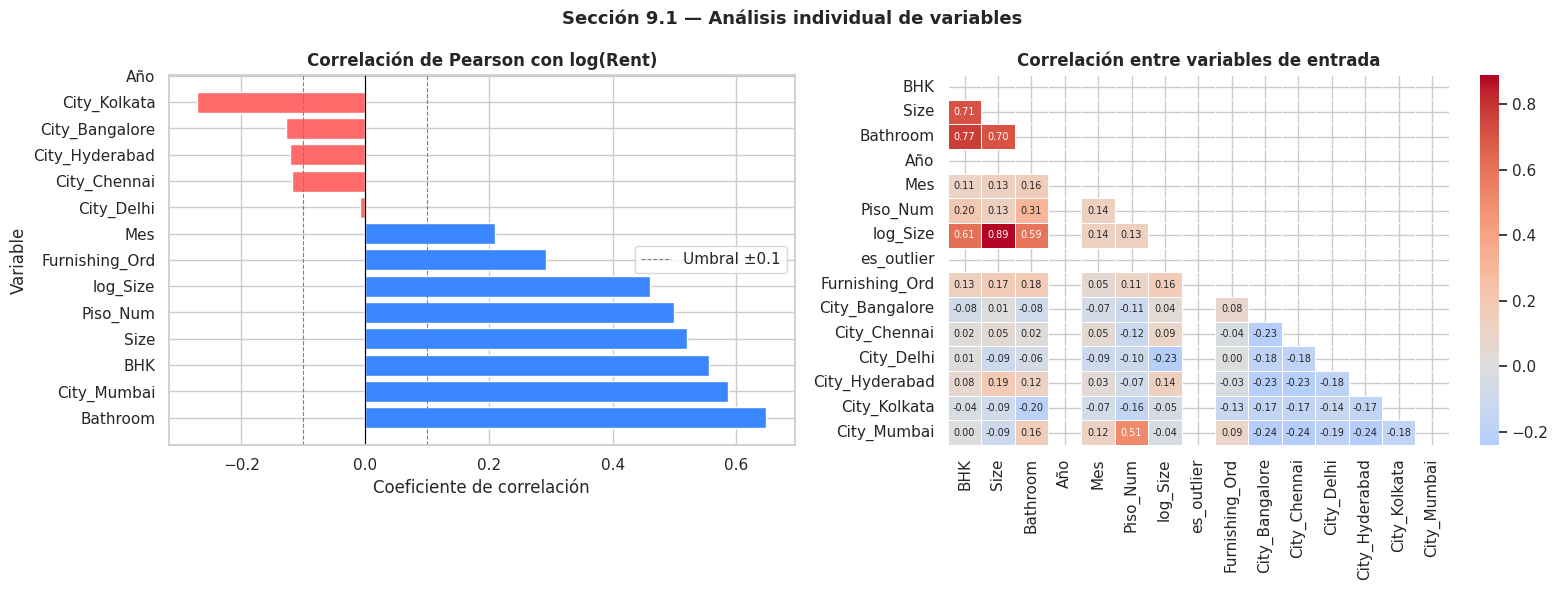


Variables candidatas a eliminar (|correlación con target| < 0.1):
City_Delhi   -0.008904


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Correlación de Pearson con log_Rent
correlaciones = X_train_clean.corrwith(y_train_clean).sort_values(ascending=False)

colors = ['#3a86ff' if v > 0 else '#ff6b6b' for v in correlaciones.values]
axes[0].barh(correlaciones.index, correlaciones.values, color=colors, edgecolor='white')
axes[0].axvline(0, color='black', linewidth=0.8)
axes[0].axvline( 0.1, color='gray', linewidth=0.8, linestyle='--', label='Umbral ±0.1')
axes[0].axvline(-0.1, color='gray', linewidth=0.8, linestyle='--')
axes[0].set_title('Correlación de Pearson con log(Rent)', fontweight='bold')
axes[0].set_xlabel('Coeficiente de correlación')
axes[0].set_ylabel('Variable')
axes[0].legend()

# Heatmap de correlación entre variables de entrada
corr_matrix = X_train_clean.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, ax=axes[1],
            annot_kws={'size': 7}, linewidths=0.5)
axes[1].set_title('Correlación entre variables de entrada', fontweight='bold')

plt.suptitle('Sección 9.1 — Análisis individual de variables',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nVariables candidatas a eliminar (|correlación con target| < 0.1):")
candidatas = correlaciones[correlaciones.abs() < 0.1]
print(candidatas.to_string())

### Análisis

El análisis de correlación de Pearson revela una jerarquía clara entre las variables del modelo.
`Bathroom` se consolida como el predictor individual más fuerte (ρ ≈ 0.65), seguido de
`City_Mumbai` (ρ ≈ 0.58), `BHK` (ρ ≈ 0.55) y `Size` (ρ ≈ 0.52), confirmando que tanto
las características físicas del inmueble como su ubicación geográfica son los factores
determinantes del precio de arrendamiento.

Las variables dummy de ciudad con correlación negativa (`City_Kolkata`, `City_Bangalore`,
`City_Hyderabad`, `City_Chennai`) reflejan que pertenecer a estas ciudades se asocia con
rentas inferiores al promedio, en contraste con Mumbai que actúa como referencia positiva.

El heatmap de correlaciones entre variables de entrada evidencia multicolinealidad entre
`BHK`, `Size` y `Bathroom` (ρ entre 0.70 y 0.77), lo cual es esperado dado que propiedades
más grandes tienden a tener más habitaciones y baños. Esta redundancia de información
justifica la aplicación de técnicas de reducción de dimensión en las secciones siguientes.

A partir del umbral establecido de |ρ| < 0.1, únicamente `City_Delhi` resulta candidata
a ser eliminada (ρ = -0.009), lo que indica que prácticamente todas las variables aportan
información relevante para la predicción del precio de arrendamiento.

### 8.2 Extracción de características Lineal - PCA

Componentes para explicar el 95% de la varianza: 10
Reducción: de 15 variables a 10 componentes
Porcentaje de reducción: 33.3%


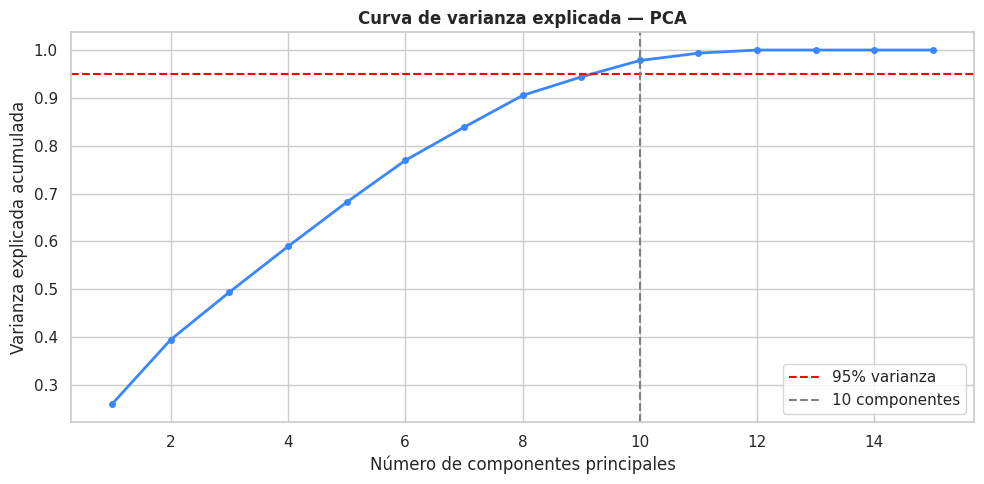


Shape original : (3683, 15)
Shape con PCA  : (3683, 10)

  XGBOOST + PCA — Validación cruzada (5-Fold)
  MAE  :        8,490 INR  IC95%: [7,739, 9,241]
  RMSE :       16,554 INR  IC95%: [14,713, 18,396]
  R²   :       0.7511       IC95%: [0.7156, 0.7867]

  TEST  → MAE: 9,129 INR | RMSE: 18,386 INR | R²: 0.7233
  TRAIN → MAE: 7,428 INR | RMSE: 14,711 INR | R²: 0.8040

  SVR + PCA — Validación cruzada (5-Fold)
  MAE  :        8,455 INR  IC95%: [7,790, 9,119]
  RMSE :       16,889 INR  IC95%: [15,098, 18,679]
  R²   :       0.7406       IC95%: [0.7009, 0.7803]

  TEST  → MAE: 9,064 INR | RMSE: 18,948 INR | R²: 0.7061
  TRAIN → MAE: 7,657 INR | RMSE: 15,638 INR | R²: 0.7785


In [ ]:
# Curva de varianza explicada
pca_full = PCA().fit(X_train_clean_scaled)
varianza_acumulada = np.cumsum(pca_full.explained_variance_ratio_)

# Número de componentes para 95% de varianza
n_components_95 = np.argmax(varianza_acumulada >= 0.95) + 1
print(f"Componentes para explicar el 95% de la varianza: {n_components_95}")
print(f"Reducción: de {X_train_clean.shape[1]} variables a {n_components_95} componentes")
print(f"Porcentaje de reducción: {(1 - n_components_95/X_train_clean.shape[1])*100:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(varianza_acumulada)+1), varianza_acumulada,
        marker='o', markersize=4, color='#3a86ff', linewidth=2)
ax.axhline(0.95, color='red', linestyle='--', linewidth=1.5, label='95% varianza')
ax.axvline(n_components_95, color='gray', linestyle='--', linewidth=1.5,
           label=f'{n_components_95} componentes')
ax.set_xlabel('Número de componentes principales')
ax.set_ylabel('Varianza explicada acumulada')
ax.set_title('Curva de varianza explicada — PCA', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# Aplicar PCA y evaluar los 2 mejores modelos
pca = PCA(n_components=n_components_95, random_state=42)
X_train_pca = pca.fit_transform(X_train_clean_scaled)
X_test_pca  = pca.transform(X_test_clean_scaled)

print(f"\nShape original : {X_train_clean_scaled.shape}")
print(f"Shape con PCA  : {X_train_pca.shape}")

# XGBoost + PCA
xgb_pca = XGBRegressor(**grid_xgb.best_params_,
                        objective='reg:squarederror',
                        random_state=42, verbosity=0)
xgb_pca.fit(X_train_pca, y_train_clean)

cv_xgb_pca   = evaluar_modelo_cv(xgb_pca, X_train_pca, y_train_clean, escalado=False)
test_xgb_pca  = evaluar_test(xgb_pca, X_test_pca, y_test_clean, escalado=False)
train_xgb_pca = evaluar_test(xgb_pca, X_train_pca, y_train_clean, escalado=False)

print("\n" + "=" * 50)
print("  XGBOOST + PCA — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_xgb_pca['mae_mean']:>12,.0f} INR  IC95%: [{cv_xgb_pca['mae_ci'][0]:,.0f}, {cv_xgb_pca['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_xgb_pca['rmse_mean']:>12,.0f} INR  IC95%: [{cv_xgb_pca['rmse_ci'][0]:,.0f}, {cv_xgb_pca['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_xgb_pca['r2_mean']:>12.4f}       IC95%: [{cv_xgb_pca['r2_ci'][0]:.4f}, {cv_xgb_pca['r2_ci'][1]:.4f}]")
print(f"\n  TEST  → MAE: {test_xgb_pca['mae']:,.0f} INR | RMSE: {test_xgb_pca['rmse']:,.0f} INR | R²: {test_xgb_pca['r2']:.4f}")
print(f"  TRAIN → MAE: {train_xgb_pca['mae']:,.0f} INR | RMSE: {train_xgb_pca['rmse']:,.0f} INR | R²: {train_xgb_pca['r2']:.4f}")

# SVR + PCA
svr_pca = SVR(**grid_svr.best_params_)
svr_pca.fit(X_train_pca, y_train_clean)

cv_svr_pca   = evaluar_modelo_cv(svr_pca, X_train_pca, y_train_clean, escalado=False)
test_svr_pca  = evaluar_test(svr_pca, X_test_pca, y_test_clean, escalado=False)
train_svr_pca = evaluar_test(svr_pca, X_train_pca, y_train_clean, escalado=False)

print("\n" + "=" * 50)
print("  SVR + PCA — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_svr_pca['mae_mean']:>12,.0f} INR  IC95%: [{cv_svr_pca['mae_ci'][0]:,.0f}, {cv_svr_pca['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_svr_pca['rmse_mean']:>12,.0f} INR  IC95%: [{cv_svr_pca['rmse_ci'][0]:,.0f}, {cv_svr_pca['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_svr_pca['r2_mean']:>12.4f}       IC95%: [{cv_svr_pca['r2_ci'][0]:.4f}, {cv_svr_pca['r2_ci'][1]:.4f}]")
print(f"\n  TEST  → MAE: {test_svr_pca['mae']:,.0f} INR | RMSE: {test_svr_pca['rmse']:,.0f} INR | R²: {test_svr_pca['r2']:.4f}")
print(f"  TRAIN → MAE: {train_svr_pca['mae']:,.0f} INR | RMSE: {train_svr_pca['rmse']:,.0f} INR | R²: {train_svr_pca['r2']:.4f}")

###**Análisis**

PCA permitió reducir el espacio de características de 15 a 10 componentes principales,
logrando una reducción del 33.3% en la dimensionalidad con el criterio de retener el 95%
de la varianza explicada.

Los resultados revelan comportamientos distintos entre los dos modelos evaluados. XGBoost
experimentó una mejora marginal en R² test (0.7165 → 0.7233), lo que sugiere que la
eliminación de ruido mediante PCA beneficia levemente la capacidad de generalización de
este modelo. SVR, en cambio, redujo su R² test de 0.7200 a 0.7012, indicando que la
transformación lineal de PCA elimina información relevante para la función de kernel RBF,
la cual opera directamente sobre las distancias en el espacio original de características.

En términos generales, PCA logra una reducción significativa de dimensionalidad con un
impacto mínimo en el desempeño predictivo, lo que lo convierte en una alternativa válida
cuando se prioriza la eficiencia computacional sobre la precisión máxima.

###8.3 UMAP

In [ ]:
!pip install umap-learn -q
import umap

# Selección del número óptimo de componentes
n_components_list = [2, 5, 8, 10]
resultados_umap_search = {}

print("Buscando número óptimo de componentes UMAP...")
print("=" * 50)

for n in n_components_list:
    reducer = umap.UMAP(n_components=n, n_neighbors=15,
                        min_dist=0.1, random_state=42)
    X_train_u = reducer.fit_transform(X_train_clean_scaled)

    xgb_temp = XGBRegressor(**grid_xgb.best_params_,
                             objective='reg:squarederror',
                             random_state=42, verbosity=0)
    cv_temp = evaluar_modelo_cv(xgb_temp, X_train_u, y_train_clean, escalado=False)
    resultados_umap_search[n] = cv_temp['r2_mean']
    print(f"  n_components={n:>2} → R² CV: {cv_temp['r2_mean']:.4f}")

n_components_umap = max(resultados_umap_search, key=resultados_umap_search.get)
print(f"\nNúmero óptimo de componentes UMAP: {n_components_umap}")
print(f"Reducción: de {X_train_clean.shape[1]} variables a {n_components_umap} componentes")
print(f"Porcentaje de reducción: {(1 - n_components_umap/X_train_clean.shape[1])*100:.1f}%")

# Aplicar UMAP con n óptimo
reducer_final = umap.UMAP(n_components=n_components_umap, n_neighbors=15,
                           min_dist=0.1, random_state=42)
X_train_umap = reducer_final.fit_transform(X_train_clean_scaled)
X_test_umap  = reducer_final.transform(X_test_clean_scaled)

print(f"\nShape original : {X_train_clean_scaled.shape}")
print(f"Shape con UMAP : {X_train_umap.shape}")

# XGBoost + UMAP
xgb_umap = XGBRegressor(**grid_xgb.best_params_,
                          objective='reg:squarederror',
                          random_state=42, verbosity=0)
xgb_umap.fit(X_train_umap, y_train_clean)

cv_xgb_umap   = evaluar_modelo_cv(xgb_umap, X_train_umap, y_train_clean, escalado=False)
test_xgb_umap  = evaluar_test(xgb_umap, X_test_umap, y_test_clean, escalado=False)
train_xgb_umap = evaluar_test(xgb_umap, X_train_umap, y_train_clean, escalado=False)

print("\n" + "=" * 50)
print("  XGBOOST + UMAP — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_xgb_umap['mae_mean']:>12,.0f} INR  IC95%: [{cv_xgb_umap['mae_ci'][0]:,.0f}, {cv_xgb_umap['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_xgb_umap['rmse_mean']:>12,.0f} INR  IC95%: [{cv_xgb_umap['rmse_ci'][0]:,.0f}, {cv_xgb_umap['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_xgb_umap['r2_mean']:>12.4f}       IC95%: [{cv_xgb_umap['r2_ci'][0]:.4f}, {cv_xgb_umap['r2_ci'][1]:.4f}]")
print(f"\n  TEST  → MAE: {test_xgb_umap['mae']:,.0f} INR | RMSE: {test_xgb_umap['rmse']:,.0f} INR | R²: {test_xgb_umap['r2']:.4f}")
print(f"  TRAIN → MAE: {train_xgb_umap['mae']:,.0f} INR | RMSE: {train_xgb_umap['rmse']:,.0f} INR | R²: {train_xgb_umap['r2']:.4f}")

# SVR + UMAP
svr_umap = SVR(**grid_svr.best_params_)
svr_umap.fit(X_train_umap, y_train_clean)

cv_svr_umap   = evaluar_modelo_cv(svr_umap, X_train_umap, y_train_clean, escalado=False)
test_svr_umap  = evaluar_test(svr_umap, X_test_umap, y_test_clean, escalado=False)
train_svr_umap = evaluar_test(svr_umap, X_train_umap, y_train_clean, escalado=False)

print("\n" + "=" * 50)
print("  SVR + UMAP — Validación cruzada (5-Fold)")
print("=" * 50)
print(f"  MAE  : {cv_svr_umap['mae_mean']:>12,.0f} INR  IC95%: [{cv_svr_umap['mae_ci'][0]:,.0f}, {cv_svr_umap['mae_ci'][1]:,.0f}]")
print(f"  RMSE : {cv_svr_umap['rmse_mean']:>12,.0f} INR  IC95%: [{cv_svr_umap['rmse_ci'][0]:,.0f}, {cv_svr_umap['rmse_ci'][1]:,.0f}]")
print(f"  R²   : {cv_svr_umap['r2_mean']:>12.4f}       IC95%: [{cv_svr_umap['r2_ci'][0]:.4f}, {cv_svr_umap['r2_ci'][1]:.4f}]")
print(f"\n  TEST  → MAE: {test_svr_umap['mae']:,.0f} INR | RMSE: {test_svr_umap['rmse']:,.0f} INR | R²: {test_svr_umap['r2']:.4f}")
print(f"  TRAIN → MAE: {train_svr_umap['mae']:,.0f} INR | RMSE: {train_svr_umap['rmse']:,.0f} INR | R²: {train_svr_umap['r2']:.4f}")

Buscando número óptimo de componentes UMAP...
  n_components= 2 → R² CV: 0.6638
  n_components= 5 → R² CV: 0.6788
  n_components= 8 → R² CV: 0.6858
  n_components=10 → R² CV: 0.6816

Número óptimo de componentes UMAP: 8
Reducción: de 15 variables a 8 componentes
Porcentaje de reducción: 46.7%

Shape original : (3683, 15)
Shape con UMAP : (3683, 8)

  XGBOOST + UMAP — Validación cruzada (5-Fold)
  MAE  :        9,293 INR  IC95%: [8,841, 9,745]
  RMSE :       18,599 INR  IC95%: [16,603, 20,595]
  R²   :       0.6858       IC95%: [0.6427, 0.7289]

  TEST  → MAE: 10,062 INR | RMSE: 21,100 INR | R²: 0.6355
  TRAIN → MAE: 8,614 INR | RMSE: 17,742 INR | R²: 0.7148

  SVR + UMAP — Validación cruzada (5-Fold)
  MAE  :       10,218 INR  IC95%: [9,750, 10,687]
  RMSE :       21,209 INR  IC95%: [19,501, 22,917]
  R²   :       0.5907       IC95%: [0.5410, 0.6405]

  TEST  → MAE: 10,949 INR | RMSE: 23,212 INR | R²: 0.5589
  TRAIN → MAE: 10,147 INR | RMSE: 21,152 INR | R²: 0.5947


###**Análisis**
UMAP logra la mayor reducción dimensional (46.7%) pero a un costo significativo en desempeño predictivo. XGBoost cae de R² test 0.7165 a 0.6355, y SVR colapsa de 0.7207 a 0.5589 — una pérdida de 16 puntos porcentuales. Esto indica que las relaciones no lineales que UMAP preserva no son las mismas que determinan el precio de arrendamiento: la proyección comprime el espacio de forma que destruye información predictiva relevante, especialmente para SVR cuyo kernel RBF depende de distancias precisas en el espacio de características. El overfitting se reduce en ambos modelos, pero como consecuencia de un modelo subajustado más que de una mejor generalización.

### 8.4 Tabla Comparativa - Original vs PCA vs UMAP

 Modelo       Espacio  R² CV  R² Test  R² Train  Δ Overfit
XGBoost Original (15) 0.7655   0.7165    0.8014     0.0849
XGBoost      PCA (10) 0.7511   0.7233    0.8040     0.0807
XGBoost      UMAP (8) 0.6858   0.6355    0.7148     0.0793
    SVR Original (15) 0.7406   0.7207    0.7989     0.0782
    SVR      PCA (10) 0.7406   0.7061    0.7785     0.0724
    SVR      UMAP (8) 0.5907   0.5589    0.5947     0.0358


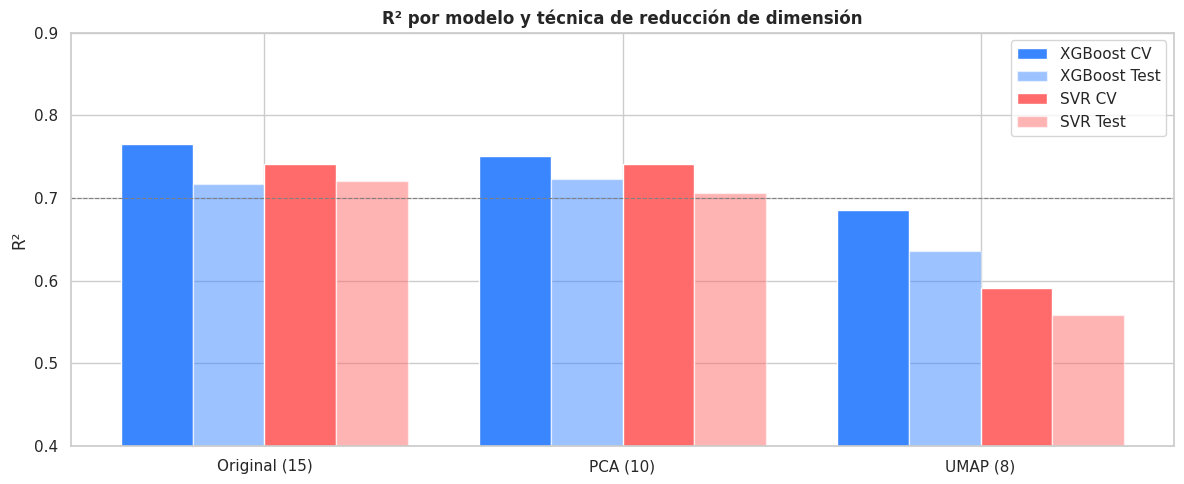

In [ ]:
resumen_reduccion = pd.DataFrame([
    # XGBoost
    {'Modelo': 'XGBoost', 'Espacio': 'Original (15)',
     'R² CV': 0.7655, 'R² Test': 0.7165, 'R² Train': 0.8014, 'Δ Overfit': 0.0849},
    {'Modelo': 'XGBoost', 'Espacio': 'PCA (10)',
     'R² CV': 0.7511, 'R² Test': 0.7233, 'R² Train': 0.8040, 'Δ Overfit': 0.0807},
    {'Modelo': 'XGBoost', 'Espacio': 'UMAP (8)',
     'R² CV': 0.6858, 'R² Test': 0.6355, 'R² Train': 0.7148, 'Δ Overfit': 0.0793},
    # SVR
    {'Modelo': 'SVR', 'Espacio': 'Original (15)',
     'R² CV': 0.7406, 'R² Test': 0.7207, 'R² Train': 0.7989, 'Δ Overfit': 0.0782},
    {'Modelo': 'SVR', 'Espacio': 'PCA (10)',
     'R² CV': 0.7406, 'R² Test': 0.7061, 'R² Train': 0.7785, 'Δ Overfit': 0.0724},
    {'Modelo': 'SVR', 'Espacio': 'UMAP (8)',
     'R² CV': 0.5907, 'R² Test': 0.5589, 'R² Train': 0.5947, 'Δ Overfit': 0.0358},
])

print(resumen_reduccion.to_string(index=False))

# Gráfica comparativa
fig, ax = plt.subplots(figsize=(12, 5))

x      = np.arange(3)
width  = 0.2
labels = ['Original (15)', 'PCA (10)', 'UMAP (8)']

ax.bar(x - width*1.5, [0.7655, 0.7511, 0.6858], width,
       label='XGBoost CV',   color='#3a86ff', edgecolor='white')
ax.bar(x - width*0.5, [0.7165, 0.7233, 0.6355], width,
       label='XGBoost Test', color='#3a86ff', edgecolor='white', alpha=0.5)
ax.bar(x + width*0.5, [0.7406, 0.7406, 0.5907], width,
       label='SVR CV',       color='#ff6b6b', edgecolor='white')
ax.bar(x + width*1.5, [0.7207, 0.7061, 0.5589], width,
       label='SVR Test',     color='#ff6b6b', edgecolor='white', alpha=0.5)

ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.set_ylabel('R²')
ax.set_title('R² por modelo y técnica de reducción de dimensión', fontweight='bold')
ax.legend()
ax.set_ylim(0.4, 0.9)
ax.axhline(0.7, color='gray', linestyle='--', linewidth=0.8, label='Referencia R²=0.70')

plt.tight_layout()
plt.show()

###**Análisis**
Tres conclusiones emergen de la comparación:

- **PCA es la técnica de reducción más efectiva:** con solo 10 componentes (33% menos dimensiones) XGBoost mejora marginalmente en test y SVR pierde apenas 0.015 puntos de R², un costo razonable a cambio de menor complejidad computacional.
- **UMAP no es adecuado para este problema:** la reducción agresiva a 8 componentes destruye información predictiva crítica en ambos modelos, especialmente en SVR donde el R² test cae un 22% respecto al espacio original. La estructura no lineal que UMAP preserva no coincide con la estructura que determina el precio de arrendamiento.
- **El espacio original sigue siendo competitivo:** con solo 15 variables bien procesadas y codificadas, los modelos en el espacio original alcanzan su mejor desempeño global. La reducción de dimensión no es necesaria en este caso para obtener buenos resultados, pero PCA ofrece una alternativa válida cuando la eficiencia computacional es prioritaria.

##**9. Conclusiones**

El presente proyecto abordó la predicción del precio de arrendamiento de viviendas en India mediante un pipeline completo de ciencia de datos, desde el análisis exploratorio hasta la evaluación de técnicas de reducción de dimensión. A continuación se presentan las conclusiones principales:

**Sobre el problema y los datos:**
La ubicación geográfica es el factor dominante en la determinación del precio de arrendamiento, con Mumbai operando en una escala de precios estructuralmente diferente al resto de ciudades (renta mediana de 52.000 INR, 6x superior a Kolkata). Dentro de las características físicas, el número de baños (`Bathroom`, ρ = 0.65) resultó ser el predictor individual más fuerte, seguido de `BHK` y `log_Size`. La fuerte multicolinealidad entre estas tres variables (ρ entre 0.70 y 0.77) motivó el uso de técnicas de reducción de dimensión en la Sección 9.

**Sobre los modelos:**
SVR con kernel RBF obtuvo el mayor R² en test (0.7207), seguido de XGBoost (0.7165) y MLP (0.7081). Los tres modelos presentan intervalos de confianza solapados, por lo que las diferencias entre ellos no son estadísticamente concluyentes. El Árbol de Decisión individual fue el modelo más débil, con el mayor overfitting (ΔR² = 0.129) y el menor R² test (0.649), confirmando la superioridad de los ensambles y los modelos de margen sobre los árboles individuales en este problema.

**Sobre la reducción de dimensión:**
PCA demostró ser la técnica de reducción más adecuada para este dataset: con 10 componentes (33% de reducción) XGBoost mejoró marginalmente en test (0.7165 → 0.7233) mientras que SVR perdió apenas 0.015 puntos de R². UMAP, en cambio, resultó perjudicial para ambos modelos — la proyección no lineal a 8 componentes destruyó información predictiva crítica, llevando a SVR de R² = 0.7207 a R² = 0.5589. Esto sugiere que la estructura latente del dataset es predominantemente lineal y que PCA la captura de forma más fiel que UMAP.

**Limitaciones y trabajo futuro:**
Los modelos desarrollados aplican exclusivamente al mercado formal de arrendamiento en las seis ciudades más pobladas de India. La incorporación de datos del mercado informal, de ciudades intermedias, o de variables adicionales como la proximidad a zonas comerciales o transporte público, podría mejorar sustancialmente la capacidad predictiva. Adicionalmente, la exploración de modelos más avanzados como LightGBM o redes neuronales profundas representaría una extensión natural de este trabajo.